In [ ]:
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Intro to Google Gemini Enterprise Demo/POV Accelerator <br> (go/gemini-ent-express)



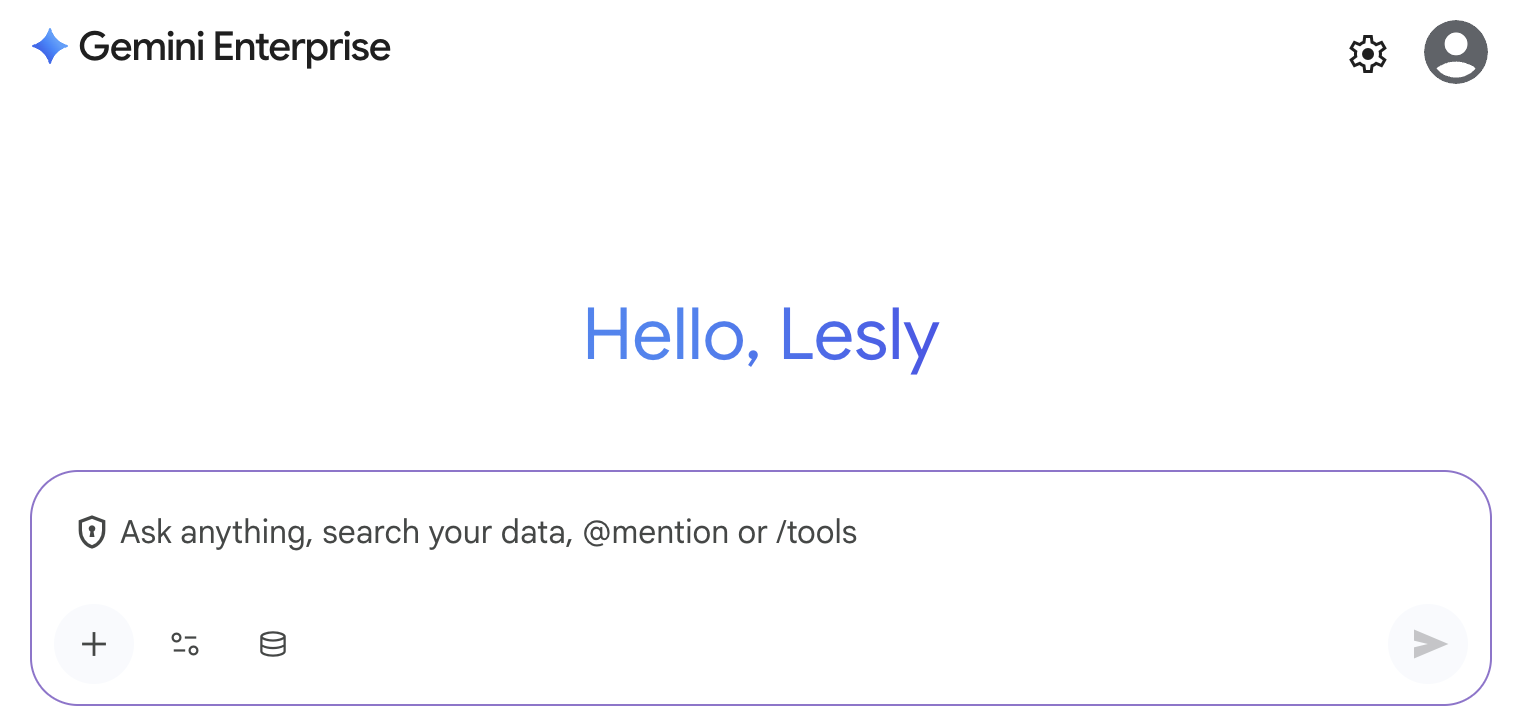

<table align="left">
  <td style="text-align: center">
    <a href="http://go/geminienterprise-demo-accelerator-video">
      <img width="90px" src="https://www.gstatic.com/youtube/img/branding/youtubelogo/svg/youtubelogo.svg" alt="Google Colaboratory logo"><br><br> See in action with a video
    </a>
  </td>
    <td style="text-align: center">
    <a href="https://colab.sandbox.google.com/">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Open in collab
    </a>
  </td>


</table>
<div style="clear: both;"></div>


| | |
|-|-|
| Author(s) | [Lesly Merine-Lecocq](mailto:leslym@google.com)
| Last update | 19 OCT 2025

## Overview

[Google Gemini Enterprise](https://cloud.google.com/products/agentspace)  brings the best of Google AI to every employee through an intuitive chat interface that acts as a single front door for AI in the workplace

This notebook is a step by step tutorial to set-up Gemini Enterprise demo with exhaustive material to get your demo or proof of value up and running (very) fast. Focus the energy on the business value, not the tech setup.
<br><br>
##### ***CHANGELOGS***
V0.6
- Add Model Armor set up

V0.5
- Add abilty to create new connectors/data store on existing engine/app as Colab runtime expires and wipe variables for previously created Gemini Enterprise apps
- Fix bugs with Sharepoint Federated Data Store

V0.4
- Add automatic creation of Gemini Enterprise subscription

V0.3
- Fix bugs and select by default the up to 100 WIF setup with Entra ID instead of the extended attributes setup that requires additionnal configuration

V0.2
- Add Sharepoint Connector Ingested

V0.1
- Add Gemini Enterprise Workforce identity Federation setup with Entra ID




#### Notebook capabilities (contact me @leslym if want to influence the upcoming capabilities)
|                                                 | Entra ID (federated with WIF) | Entra ID (synchronized with Cloud Identity) | Cloud Identity |
|-------------------------------------------------|-------------------------------|---------------------------------------------|----------------|
| **Third party data sources** |                               |                                             |                |
| Sharepoint Ingested                             | ✅                            | P2                                          | P2             |
| Sharepoint Federated                            | ✅                            | P2                                          | P2             |
| One Drive Ingested                              | ✅                            | P2                                          | P2             |
| One Drive Federated                             | ✅                            | P2                                          | P2             |
| Entra ID (as a data source - i.e. people)       | P3                            | P2                                          | P2             |
| **Third party actions** |                               |                                             |                |
| Outlook calendar and email actions              | P1                            | P2                                          | P2             |
| Jira Cloud actions                              | P1                            | P2                                          | P2             |
| **Google data sources** |                               |                                             |                |
| GMail                                           | P2                            | P2                                          | P2             |
| Google Drive                                    | P2                            | P2                                          | P2             |

<br>
As Gemini Enterprise is a fast moving product, this notebook will evolve as fast as I can to follow the pace. Do not hesitate to contribute.

✅ = Working capability

🚧 = Work in progess

**THIS NOTEBOOK IS FOR DEMO/POV ONLY, THIS IS NOT PRODUCTION READY, PLEASE DO NOT USE IT AS IS FOR PRODUCTION.**

**Reference:**

- https://cloud.google.com/gemini/enterprise/docs
- https://github.com/GoogleCloudPlatform/generative-ai
- https://cloud.google.com/gemini/enterprise/docs/get-started

# ✅ Set Google Cloud project information and Collab environment

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

**If you don't know your project ID**, try the following:

* Run `gcloud config list`.
* Run `gcloud projects list`.
* See the support page: [Locate the project ID](https://support.google.com/googleapi/answer/7014113)

In [ ]:
# @title Install client library
# @markdown Install the following packages required to execute this notebook.
%pip install --upgrade --quiet google-cloud-discoveryengine


In [ ]:
# @title Restart runtime
# @markdown To use the newly installed packages in this Jupyter runtime, you must restart the runtime. You can do this by running the cell below, which restarts the current kernel. The restart might take a minute or longer. After it's restarted, continue to the next step.

import IPython

app = IPython.Application.instance()
app.kernel.do_shutdown(True)

In [ ]:
# @title Set Google Cloud project information

# Use the environment variable if the user doesn't provide Project ID.
import os

LOCATION = "global"  # @param {type: "string", placeholder: "[global | eu | us]"}


ORGANIZATION_ID = "1028075411062"  # @param {type: "string" , placeholder: "[your-org-id]"}
PROJECT_ID = "my-project-2110-475722"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
# @markdown ---
# @markdown (fill only if you want to create new connectors/data stores to an existing Gemini Enteprise app/engine)

ENGINE_ID = "my-first-geminienterprise-app"  # @param {type: "string", placeholder: "[your-engine-id]"}
WORKFORCE_POOL_ID = "entra-id-oidc-pool-wnse"  # @param {type: "string", placeholder: "[your-workforce-pool-id]"}
WORKFORCE_PROVIDER_ID = "entra-id-oidc-pool-provider-wnse"  # @param {type: "string", placeholder: "[your-workforce-provider-id]"}

if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

!gcloud config set project {PROJECT_ID}


In [ ]:
# @title Authenticate your notebook environment (Colab only)
# @markdown If you're running this notebook on Google Colab, run the cell below to authenticate your environment.
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

In [ ]:
# @title Enable APIs
!gcloud services enable discoveryengine.googleapis.com aiplatform.googleapis.com discoveryengine.googleapis.com storage.googleapis.com iam.googleapis.com compute.googleapis.com
#enable data access logs for security token service

!gcloud services enable logging.googleapis.com

In [ ]:
# @title Checking internet connection for this notebook
import requests

def check_internet_connection(url='https://www.google.com', timeout=5):
    """
    Checks for a stable internet connection by sending a request to a URL.

    Args:
        url (str): The URL to check. Defaults to Google.
        timeout (int): The number of seconds to wait for a response.

    Returns:
        bool: True if the connection is successful, False otherwise.
    """
    try:
        # Using a HEAD request for efficiency
        response = requests.head(url, timeout=timeout)
        # A status code of 200 means OK
        return response.status_code == 200
    except requests.RequestException:
        # Catches any request-related errors (e.g., connection timeout, DNS error)
        return False

# --- Example Usage ---
if __name__ == "__main__":
    if check_internet_connection():
        print("✅ Internet connection is active.")
    else:
        print("❌ Internet connection is down.")

In [ ]:
# @title (\*only if Colab does not have access to a network with Internet) Create default network on the project to get access to the internet within Colab
# @markdown ***REMINDER: DO NOT USE THIS NOTEBOOK FOR PRODUCTION***


NETWORK_NAME="default"
SUBNET_NAME="default"
REGION="europe-west1"


!gcloud compute networks create {NETWORK_NAME}

# create cloud router
!gcloud compute routers create default --network {NETWORK_NAME} --region={REGION}

# create cloud nat to access to the internet
!gcloud compute routers nats create default  --region={REGION} --router {NETWORK_NAME} --auto-allocate-nat-external-ips --nat-all-subnet-ip-ranges


In [ ]:
# @title Import libraries

from google.api_core.client_options import ClientOptions
from google.cloud import discoveryengine_v1 as discoveryengine
from google.protobuf.json_format import MessageToDict

In [ ]:
# @title Install Azure CLI
# @markdown This only needs to be run once per session.
#!curl -sL https://aka.ms/InstallAzureCLIDeb | sudo bash
!curl -sL https://aka.ms/InstallAzureCLIDeb | sudo bash > /dev/null && echo "✅ Azure CLI installed successfully." || echo "❌ Error installing Azure CLI."

In [ ]:
# @title Login to Azure
!az login --allow-no-subscriptions

# ✅ Configure a Gemini Enterprise app with identity provider

## ✅ Setting up the Gemini Enteprise App

- Based on official doc [here](https://cloud.google.com/gemini/enterprise/docs/create-app).


In [ ]:
import subprocess
import shlex

# --- 1. YOUR VARIABLES (ASSUMED TO BE SET UP) ---
# PROJECT_ID = "your-project-id"
# DATA_STORE_ID = "your-data-store-id"
ENGINE_ID = "my-first-geminienterprise-app" # @param {type:"string"}
LICENSE_CONFIG_ID = "my-first-geminienterprise-license" # @param {type:"string"}
ENGINE_NAME = "My First Gemini Enterprise App" # @param {type:"string"}
COMPANY_NAME = "Cymbal Bank" # @param {type:"string", placeholder:"Type your company name to help improve LLM related features"}


# --- 2. CONSTRUCT THE COMMAND ---
command = f"""
curl -X POST \
-H "Authorization: Bearer $(gcloud auth print-access-token)" \
-H "Content-Type: application/json" \
-H "X-Goog-User-Project: {PROJECT_ID}" \
"https://discoveryengine.googleapis.com/v1/projects/{PROJECT_ID}/locations/global/collections/default_collection/engines?engineId={ENGINE_ID}" \
-d '{{
  "displayName": "{ENGINE_NAME}",
  "solutionType": "SOLUTION_TYPE_SEARCH",
  "industryVertical": "GENERIC",
  "appType": "APP_TYPE_INTRANET",
  "commonConfig": {{
    "companyName": "{COMPANY_NAME}"
  }}
}}'
"""

# --- 3. EXECUTE AND PRINT THE DETAILED OUTPUT ---
print("🚀 Executing command...")
# The 'shell=True' argument is needed to process shell features like $(gcloud...)
# 'capture_output=True' and 'text=True' capture the command's text output
result = subprocess.run(command, shell=True, capture_output=True, text=True)

# Check if the command was successful (an exit code of 0 means success)
if result.returncode == 0:
    print("✅ Command executed successfully!")
    print("\n--- API Response (stdout) ---")
    print(result.stdout)
else:
    print(f"❌ Command failed with exit code: {result.returncode}")
    print("\n--- Error Details (stderr) ---")
    print(result.stderr)

## Configure identity provider
- Option 1: Cloud Identity
- Option 2: Workforce identity federation with Entra ID

**Source**: https://cloud.google.com/gemini/enterprise/docs/configure-identity-provider

### Option 1: Cloud identity
- Go to identity provider configuration page of your [Gemini Enterprise App](https://console.cloud.google.com/gemini-enterprise/locations/global/engines/my-first-geminienterprise-app/overview/identity?orgonly=true&walkthrough_id=gemini-enterprise--identity-v1--create--quickstart)
- Select "Use Google Identity" if your Cloud Identity is your main IdP. If not, you can continue.

### Option 2: Workforce identity federation with Entra ID
## Create a Microsoft Entra ID application


In [ ]:
# @title Create the Azure App
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Workforce ID Federation "+random_suffix  # @param {type:"string"}
WORKFORCE_POOL_ID = f"entra-id-oidc-pool-{random_suffix}"  # @param {type:"string"}
WORKFORCE_PROVIDER_ID = f"entra-id-oidc-pool-provider-{random_suffix}"  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://auth.cloud.google/signin-callback/locations/global/workforcePools/{WORKFORCE_POOL_ID}/providers/{WORKFORCE_PROVIDER_ID}"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID'] = APP_ID
    print(f"   -> Set environment variable APP_ID\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

In [ ]:
# @title Create Secret, Add Permissions, and Grant Consent

## @markdown - By default, the setup can handle up to 100 Entra groups, check this if you want to use extended attributes to configure Workforce Identity Federation with the Microsoft Entra ID identity provider (IdP) and map up to 400 groups from Microsoft Entra ID to Google Cloud by using Microsoft Graph. See [doc for details on additionnal set up](https://cloud.google.com/iam/docs/workforce-sign-in-microsoft-entra-id-scalable-groups).
use_extended_attributes = False  # //@param {type:"boolean"}

# /@markdown ---

# @markdown ⬇️ Fill in the Application (client) ID of your app in the execution console.



import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    try:
        return json.loads(result.stdout) if result.stdout.strip() else {}
    except json.JSONDecodeError:
        return {"raw_output": result.stdout}

# --- 1. Create a new Client Secret ---
print("⚙️ Creating a new client secret...")
# Using 'reset' is better as it works even if a secret already exists
secret_command = ["az", "ad", "app", "credential", "reset", "--id", APP_ID]
secret_details = run_command(secret_command)
if secret_details is None or "password" not in secret_details:
    print("❌ Failed to create or retrieve client secret.", file=sys.stderr)
    sys.exit(1)

CLIENT_SECRET = secret_details.get("password")
print("👍 New client secret created successfully. SAVE THIS VALUE - it won't be shown again.")
print(f"   Client Secret: {CLIENT_SECRET}\n")

# --- 2. Define Permissions ---
print("⚙️ Defining required permissions...")
if use_extended_attributes:
  # User.Read is Delegated, User.Read.All is Application
  permissions_to_add = ["User.Read", "User.Read.All", "GroupMember.Read.All"]
else:
  permissions_to_add = ["User.Read"]
print(f"   Requesting: {permissions_to_add}\n")

# --- 3. Find Microsoft Graph and its Permission IDs ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

# This dictionary will store the permission name, its ID, and its type (Scope or Role)
required_permissions = {}

# Search Delegated permissions (oauth2PermissionScopes)
for permission in graph_sp.get("oauth2PermissionScopes", []):
    if permission.get("value") in permissions_to_add:
        required_permissions[permission.get("value")] = {"id": permission.get("id"), "type": "Scope"}

# Search Application permissions (appRoles)
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add and permission.get("isEnabled"):
        required_permissions[permission.get("value")] = {"id": permission.get("id"), "type": "Role"}

print("👍 Found necessary permission IDs.")
for name, details in required_permissions.items():
    print(f"   - {name} (Type: {details['type']})")
print("")

# --- 4. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, details in required_permissions.items():
    perm_id = details['id']
    perm_type = details['type']
    print(f"   Adding permission: {name}")
    # Construct the permission string with the correct type (e.g., GUID=Scope or GUID=Role)
    api_permission_string = f"{perm_id}={perm_type}"
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID, "--api", graph_sp["appId"], "--api-permissions", api_permission_string]
    # We run this and ignore output because changes can take a moment to show up
    subprocess.run(add_perm_command, capture_output=True)

# --- 5. Grant Admin Consent ---
print("\n⚙️ Granting admin consent... (waiting 20s for propagation)")
time.sleep(20) # Wait for permissions to be registered before granting consent
grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")

# --- 6. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client Secret:     {CLIENT_SECRET}  <-- Make sure you have saved this value")
print(f"Permissions Added: {list(required_permissions.keys())}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

In [ ]:
# @title Enable the Secret Manager API
# 1. Enable the Secret Manager API
!gcloud services enable secretmanager.googleapis.com --project={PROJECT_ID}

In [ ]:
# @title Store App Registration credentials into Secret Manager
# --- Store the Application (Client) ID ---
SECRET_NAME="EntraAppID_"+APP_ID

# --- Store the Client Secret ---
# First, check if the secret exists. If not, create it.
!gcloud secrets describe {SECRET_NAME} --project={PROJECT_ID} &> /dev/null || gcloud secrets create {SECRET_NAME} --replication-policy="automatic" --project={PROJECT_ID}

# Add the client_secret's value as a new secret version
!echo -n {CLIENT_SECRET} | gcloud secrets versions add {SECRET_NAME} --data-file=- --project={PROJECT_ID}
print(f"✅ Client Secret stored successfully as '{SECRET_NAME}'.")



In [ ]:
# @title Create a workforce identity pool
WORKFORCE_POOL_NAME = "EntraWIFPool-"+random_suffix  # @param {type:"string"}
print(f"Creating workforce pool id {WORKFORCE_POOL_ID} for organization {ORGANIZATION_ID} in {LOCATION} location)")

!gcloud iam workforce-pools create {WORKFORCE_POOL_ID} \
    --organization={ORGANIZATION_ID} \
    --display-name={WORKFORCE_POOL_NAME}  \
    --description="Entra ID Workforce identity pool" \
    --session-duration=3600s \
    --location=global

In [ ]:
# @title Create an OIDC workforce identity pool provider
PROVIDER_DISPLAY_NAME = "EntraWIFProvider-"+random_suffix  # @param {type:"string"}
ATTRIBUTE_MAPPING = '"google.groups=assertion.groups,google.subject=assertion.sub,google.display_name=assertion.preferred_username"'
ATTRIBUTE_MAPPING_upTo100 = '"google.subject=assertion.sub, google.groups=assertion.groups,google.display_name=assertion.preferred_username"'

if use_extended_attributes:
  EXTRA_ATTRIBUTES_TYPE = "azure-ad-groups-id"
  !gcloud iam workforce-pools providers create-oidc {WORKFORCE_PROVIDER_ID} \
      --workforce-pool={WORKFORCE_POOL_ID} \
      --location={LOCATION} \
      --display-name={PROVIDER_DISPLAY_NAME} \
      --issuer-uri={ISSUER_URI} \
      --client-id={APP_ID} \
      --client-secret-value={CLIENT_SECRET} \
      --attribute-mapping={ATTRIBUTE_MAPPING} \
      --detailed-audit-logging \
      --web-sso-response-type="code" \
      --web-sso-assertion-claims-behavior="merge-user-info-over-id-token-claims" \
      --extra-attributes-issuer-uri={ISSUER_URI} \
      --extra-attributes-client-id={APP_ID} \
      --extra-attributes-client-secret-value={CLIENT_SECRET} \
      --extra-attributes-type={EXTRA_ATTRIBUTES_TYPE}  \
      --extended-attributes-issuer-uri={ISSUER_URI} \
      --extended-attributes-client-id={APP_ID} \
      --extended-attributes-client-secret-value={CLIENT_SECRET} \
      --extended-attributes-type=azure-ad-groups-id \
      --detailed-audit-logging
else:
  !gcloud iam workforce-pools providers create-oidc {WORKFORCE_PROVIDER_ID} \
    --workforce-pool={WORKFORCE_POOL_ID} \
    --display-name={PROVIDER_DISPLAY_NAME} \
    --issuer-uri={ISSUER_URI} \
    --client-id={APP_ID} \
    --client-secret-value={CLIENT_SECRET} \
    --web-sso-response-type="code" \
    --web-sso-assertion-claims-behavior="merge-user-info-over-id-token-claims" \
    --attribute-mapping={ATTRIBUTE_MAPPING_upTo100} \
    --detailed-audit-logging \
    --location=global


In [ ]:
# @title (Optional) Verify Workforce Identity Federation setup
# @markdown  - Code will enable audit logs for the Data Access activity's [Security Token Service API](https://cloud.google.com/gemini/enterprise/docs/configure-identity-provider#verify-setup). (⚠️ This will be enabled at organization level as Workforce Identity pools are set up at Organization level)

# @markdown - Click on the execution result to see for Workforce identity logs - see the [doc](https://cloud.google.com/gemini/enterprise/docs/configure-identity-provider#verify-setup) for more details:
# @markdown   - Check the audit logs for an entry with the *google.identity.sts.SecurityTokenService.WebSignIn* method that matches the sign-in timestamp.
# @markdown    -  Confirm that the **metadata.mapped_attributes* field in the log matches the attribute that you used when configuring Workforce Identity Federation for third-party identity providers.
import yaml

# --- Step 1: Fetch the Current Audit Policy ---
# We save the current policy to a file named 'current_policy.yaml'.
print(f"\n Fetching the current IAM audit policy for organization {ORGANIZATION_ID}...")
!gcloud organizations get-iam-policy {ORGANIZATION_ID} > current_policy.yaml

# --- Step 2: Safely Update the Policy File ---
# This Python block reads the file, adds/updates the STS config, and saves it.
# This prevents accidentally deleting other important audit log settings.
print(" Updating the policy file to enable STS logs...")
service_to_add = 'sts.googleapis.com'
new_config = {
    'service': service_to_add,
    'auditLogConfigs': [{'logType': 'ADMIN_READ'}]
}

with open('current_policy.yaml', 'r') as f:
    policy = yaml.safe_load(f.read()) or {'auditConfigs': []}

configs = policy.get('auditConfigs', [])
if not configs:
    policy['auditConfigs'] = []

# Find and replace existing STS config or append a new one
found_and_updated = False
for i, config in enumerate(policy['auditConfigs']):
    if config.get('service') == service_to_add:
        policy['auditConfigs'][i] = new_config
        found_and_updated = True
        break
if not found_and_updated:
    policy['auditConfigs'].append(new_config)

with open('updated_policy.yaml', 'w') as f:
    yaml.dump(policy, f, sort_keys=False)
print(" Policy file 'updated_policy.yaml' created successfully.")

# --- Step 3: Apply the Updated Policy ---
# We use !gcloud again to set the new policy from our updated file.
print(f"\n Applying the updated policy to organization '{ORGANIZATION_ID}'...")
!gcloud organizations set-iam-policy {ORGANIZATION_ID} updated_policy.yaml

print("\n✅ Success! The new audit policy has been applied.")

# --- Step 6: Clean up temporary files ---
os.remove('current_policy.yaml')
os.remove('updated_policy.yaml')

print(f"🪪 Click on this link to test the setup of Workforce Identity federation: \n https://auth.cloud.google/signin/locations/{LOCATION}/workforcePools/{WORKFORCE_POOL_ID}/providers/{WORKFORCE_PROVIDER_ID}?continueUrl=https://console.cloud.google/")

print("You should see the following message in a yellow bar: ***This page has been updated for workforce identity federation users***")

print("\n✅ Clik here to see Workforce identity pool logs: ")
print(f"https://console.cloud.google.com/logs/query?advancedFilter=resource.type%3D%22audited_resource%22%20resource.labels.service%3D%22sts.googleapis.com%22%20protoPayload.resourceName:%22workforcePools%2F{WORKFORCE_POOL_ID}%22&organizationId={ORGANIZATION_ID}&walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&supportedpurview=organizationId")

## Link third party identity provider with Gemini Enterprise

In [ ]:
# @title 🛂 Create a third party identity provider
print("Visit below url to configure Gemini Enterprise authentication flow:")
# @markdown - 1/ 👇 Run cell then, visit url below
#print(f"https://console.cloud.google.com/gemini-enterprise/settings/authentication?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId \n")
print(f"https://console.cloud.google.com/gemini-enterprise/locations/{LOCATION}/engines/{ENGINE_ID}/overview/identity?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
# @markdown - 2/ Choose "***Use a third-party identity provider***""
#print(f"Location: {LOCATION}")
# @markdown - 3/ 👇 Copy/paste the details below
print(f"Workforce pool name: locations/{LOCATION}/workforcePools/{WORKFORCE_POOL_ID}")
print(f"Workforce provider ID: {WORKFORCE_PROVIDER_ID}")

# @markdown - 4/ Click "***Configure Workforce Identity***""



## ⚠️ Assign licenses and permissions to users
- Reference:
  - https://cloud.google.com/gemini/enterprise/docs/licenses#about-licenses



In [ ]:
# @title Grant IAM Role to users of your Gemini Enterprise App
# @markdown Be sure the domain is whitelisted if you have an organization policy in place (i.e. DomainRestrictedSharing)

# @markdown It is recommended to add the permission to users or group. Giving access to the whole pool is for demo/POV only, or after a proper risk analysis (i.e. when a global intranet would be open to to all employees, a Gemini Enterprise portal for HR or Finance might be restricted to a group of individuals). Read more on how to configure the federation for production on the documentation.
import subprocess
import shlex # Used to safely quote variables

GRANT_ACCESS_TO_ALL_POOL = True # @param {type:"boolean"}

# The specific role to grant for Vertex AI Search users
ROLE = "roles/discoveryengine.user"
USER_EMAILS = "lesly@withlesly.dev" #@param {type:"string", placeholder:"banana@google.com,gemini@google.com"}
# Split the comma-separated string into a list of individual emails
# and strip any extra whitespace from each email.
emails_to_add = [email.strip() for email in USER_EMAILS.split(',') if email.strip()]

if GRANT_ACCESS_TO_ALL_POOL:
    print(f"⚙️  Attempting to grant the '{ROLE}' role to {WORKFORCE_POOL_NAME} pool on project '{PROJECT_ID}'...")
    print("-" * 30)
    command = f"""
        gcloud projects add-iam-policy-binding {shlex.quote(PROJECT_ID)} \
            --member="principalSet://iam.googleapis.com/locations/{LOCATION}/workforcePools/{WORKFORCE_POOL_ID}/*" \
            --role="{ROLE}"
        """
    print(f"   -> Granting access to pool {WORKFORCE_POOL_NAME} ")

    # Execute the command
    result = subprocess.run(command, shell=True, capture_output=True, text=True)

    if result.returncode == 0:
        print("      ✅ Success!")
    else:
        # Print a concise error if one occurs
        print(f"      ❌ Failed.")
        print(f"         Error: {result.stderr.strip()}")
    print("-" * 30)

if not emails_to_add:
    print("⚠️ No email addresses were entered. Please provide at least one email.")
else:
    print(f"⚙️  Attempting to grant the '{ROLE}' role to {len(emails_to_add)} user(s) on project '{PROJECT_ID}'...")
    print("-" * 30)

    for email in emails_to_add:
        # Construct the gcloud command
        command = f"""
        gcloud projects add-iam-policy-binding {shlex.quote(PROJECT_ID)} \
            --member="principal://iam.googleapis.com/locations/{LOCATION}/workforcePools/{WORKFORCE_POOL_ID}/subject/{email}" \
            --role="{ROLE}"
        """

        print(f"   -> Granting access to: {email}")

        # Execute the command
        result = subprocess.run(command, shell=True, capture_output=True, text=True)

        if result.returncode == 0:
            print("      ✅ Success!")
        else:
            # Print a concise error if one occurs
            print(f"      ❌ Failed.")
            print(f"         Error: {result.stderr.strip()}")
        print("-" * 30)

    print("\n✅ Process complete.")

### Create Gemini Enterprise subscription

In [ ]:
# @title (Option 1) Create Gemini Enterprise free trial subscription
# @markdown It is possible that you will need to enable the subscription manually (see option 2 below)

import datetime

LICENSE_CONFIG_ID = "my-first-geminienterprise-license" # @param {type:"string"}
today = datetime.date.today()
tomorrow = today + datetime.timedelta(days=1)

# --- 2. CONSTRUCT THE COMMAND ---

# Create the payload as a Python dictionary
payload = {
  "freeTrial": True,
  "subscriptionTier": "SUBSCRIPTION_TIER_ENTERPRISE",
  "licenseCount": "25",
  "startDate": {
    "year": tomorrow.year,    # <-- Use dynamic year
    "month": tomorrow.month,  # <-- Use dynamic month
    "day": tomorrow.day       # <-- Use dynamic day
  },
  "subscriptionTerm": "SUBSCRIPTION_TERM_ONE_YEAR"
}

json_payload = shlex.quote(json.dumps(payload))

command_license = f"""
curl -X POST \
-H "Authorization: Bearer $(gcloud auth print-access-token)" \
-H "Content-Type: application/json" \
-H "X-Goog-User-Project: {PROJECT_ID}" \
"https://discoveryengine.googleapis.com/v1/projects/{PROJECT_ID}/locations/global/licenseConfigs/?licenseConfigId={LICENSE_CONFIG_ID}" \
-d {json_payload}
"""

# --- 3. EXECUTE AND PRINT THE DETAILED OUTPUT ---
print("🚀 Executing command...")
# The 'shell=True' argument is needed to process shell features like $(gcloud...)
# 'capture_output=True' and 'text=True' capture the command's text output
result = subprocess.run(command_license, shell=True, capture_output=True, text=True)

# Check if the command was successful (an exit code of 0 means success)
if result.returncode == 0:
    print("✅ Command executed successfully!")
    print("\n--- API Response (stdout) ---")
    print(result.stdout)
else:
    print(f"❌ Command failed with exit code: {result.returncode}")
    print("\n--- Error Details (stderr) ---")
    print(result.stderr)

In [ ]:
# @title Try to connect to your Gemini Enterprise App

# @markdown - Run the code to get the link to your Gemini Enterprise portal
# @markdown - If you manage to connect to the Gemini Enterprise portal, you can skip option 2.


#APP_URL = f"https://vertexaisearch.cloud.google.com/{LOCATION}/home/cid/{}}?hl=en_US"

from google.api_core.client_options import ClientOptions
from google.cloud import discoveryengine_v1 as discoveryengine

# TODO(developer): Uncomment these variables before running the sample.
# project_id = "YOUR_PROJECT_ID"
# location = "YOUR_LOCATION" # Values: "global"


def list_engines_sample(
    project_id: str,
    location: str,
) -> discoveryengine.ListEnginesResponse:
    #  For more information, refer to:
    # https://cloud.google.com/generative-ai-app-builder/docs/locations#specify_a_multi-region_for_your_data_store
    client_options = (
        ClientOptions(api_endpoint=f"{location}-discoveryengine.googleapis.com")
        if location != "global"
        else None
    )

    # Create a client
    client = discoveryengine.EngineServiceClient(client_options=client_options)

    # The full resource name of the parent collection
    # e.g. projects/{project}/locations/{location}/collections/default_collection
    parent = client.collection_path(
        project=PROJECT_ID,
        location=LOCATION,
        collection="default_collection",
    )

    # Make the request
    response = client.list_engines(parent=parent)

    # Handle response
    print(response)

    return response

#print(list_engines_sample(PROJECT_ID, LOCATION))

#print(f"Visit link to access to your Gemini Enterprise App: https://console.cloud.google.com/gemini-enterprise/apps?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")


print(f"Visit link to access to your Gemini Enterprise App: https://console.cloud.google.com/gemini-enterprise/locations/{LOCATION}/engines/{ENGINE_ID}/overview/dashboard?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")


#print(f"Visit link to access to your Gemini Enterprise App: https://auth.cloud.google/signin/locations/{LOCATION}/workforcePools/{WORKFORCE_POOL_ID}/providers/{WORKFORCE_PROVIDER_ID}?continueUrl=https%3A%2F%2Fvertexaisearch.cloud.google%2Fhome%2Fcid%{ENGINE_ID}&hl=en_US")


In [ ]:
# @title Verify the licenses assigned to users
print(f"\n See below the status of licenses attached to the project {PROJECT_ID}:")
!curl -X GET \
-H "Authorization: Bearer $(gcloud auth print-access-token)" \
-H "Content-Type: application/json" \
-H "X-Goog-User-Project: {PROJECT_ID}" \
"https://{LOCATION}-discoveryengine.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/userStores/default_user_store/userLicenses"

In [ ]:
# @title (Option 2) Create manually the Gemini Enterprise subscription
# @markdown - If the automatic (option 1) creation did not succeed, create manually the subscription (select **Assign licenses automatically** if you want the licenses to be assigned when user first logs in).
# @markdown - ⚠️ Ensure you have the permissions to attach a new subcription to the billing account that supports the project.

print(f"\n See below the status of licenses attached to the project {PROJECT_ID}:")
!curl -X GET \
-H "Authorization: Bearer $(gcloud auth print-access-token)" \
-H "Content-Type: application/json" \
-H "X-Goog-User-Project: {PROJECT_ID}" \
"https://{LOCATION}-discoveryengine.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/userStores/default_user_store/userLicenses"

print(f"⚠️ Enable the Gemini subcription and assign licenses manually on the following page:  https://console.cloud.google.com/gemini-enterprise/subscriptions?project={PROJECT_ID}")

# ✅ Set up Sharepoint Connector (data ingestion)

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- To avoid ownership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint
- Reference:
  - https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds




In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Sharepoint Ingestion "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://vertexaisearch.cloud.google.com/console/oauth/sharepoint_oauth.html"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_SHAREPOINT_INGESTED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_SHAREPOINT_INGESTED'] = APP_ID_SHAREPOINT_INGESTED
    print(f"   -> Set environment variable APP_ID_SHAREPOINT_INGESTED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_SHAREPOINT_INGESTED,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

1- On the Select a data source page, scroll or search for SharePoint Online to connect your third-party source.
2- Copy the Subject identifier.

In [ ]:
# @title Get the subject identifier to set up Federated credentials
# @markdown Execute this cell, then on the Select a data source page, scroll or search for **SharePoint** to connect your third-party source. Copy and paste the **Subject identifier here**.

print("Click here to navigate to the page where you can copy the subject identifier👇 to paste below")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId&walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart")

def get_integer(prompt="Please enter the Subject Identifier copied on the page: "):
    """
    Prompts the user for input and waits until a valid integer is entered.
    """
    while True:
        user_input = input(prompt)
        try:
            # Attempt to convert the user's input to an integer
            number = int(user_input)
            # If successful, exit the loop and return the number
            return number
        except ValueError:
            # If the conversion fails, inform the user and loop again
            print("Invalid input. Please enter a whole number.")

# --- Using the function in Colab ---
SHAREPOINT_SUB_ID = get_integer("Please paste the Subject Identifier copied on the page and click ENTER:")

print(f"\nThank you! Subject Identifier is {SHAREPOINT_SUB_ID}. You can continue.")

In [ ]:
# @title Create Federated credential, Add Permissions, and Grant Consent
# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).

SitesAllPermissions = True  # @param {type:"boolean"}

import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
issuer_uri = "https://accounts.google.com"
subject = SHAREPOINT_SUB_ID


CREDENTIAL_NAME = "GCP_Sharepoint_Federated_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Federated credential for accessing SharePoint Online from Gemini Enterprise" # @param {type:"string"}

credentials_json = {
    "name": CREDENTIAL_NAME,
    "issuer": issuer_uri,
    "subject": str(subject),
    "description": CREDENTIAL_DESCRIPTION,
    "audiences": [ "api://AzureADTokenExchange" ]
}

# Save the JSON to a temporary file
credentials_file_path = "/tmp/fed_creds.json"
with open(credentials_file_path, "w") as f:
    json.dump(credentials_json, f)

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {issuer_uri}")
print(f"   - Subject: {subject}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating federated credential '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_SHAREPOINT_INGESTED}'...")
az_command = [
    "az", "ad", "app", "federated-credential", "create",
    "--id", APP_ID_SHAREPOINT_INGESTED,
    "--parameters", f"@{credentials_file_path}"
]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Federated credential created successfully in Microsoft Entra ID.")
    print("\n--- Details ---")
    print(creation_result)


# --- 2. Find Microsoft Graph and its Permissions ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("Sites.FullControl.All")
  permissions_to_add.append("User.Read.All")
  permissions_to_add_scope = ["User.Read"] # Delegated permission

else:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("Sites.Selected")
  permissions_to_add.append("User.ReadBasic.All")
  permissions_to_add_scope = ["User.Read"] # Delegated permission


# Search Application permissions (appRoles)
required_permission_ids = {}


# Search Application permissions (appRoles)
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add and permission.get("isEnabled"):
        required_permission_ids[permission.get("value")] = {"id": permission.get("id"), "type": "Role"}

# Search Delegated permissions (oauth2PermissionScopes)
for permission in graph_sp.get("oauth2PermissionScopes", []):
    if permission.get("value") in permissions_to_add_scope:
        required_permission_ids[permission.get("value")] = {"id": permission.get("id"), "type": "Scope"}

print("👍 Found necessary permission IDs.\n")
for name, details in required_permission_ids.items():
    print(f"   - {name} (Type: {details['type']})")
print("")

# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, details in required_permission_ids.items():
    perm_id = details['id']
    perm_type = details['type']
    print(f"   Adding permission: {name}")
    api_permission_string = f"{perm_id}={perm_type}"
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", api_permission_string]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate

# --- 2b. Find Microsoft Sharepoint and its Permissions ---
print("⚙️ Finding Office 365 SharePoint Online API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 SharePoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add_sharepoint = ["Sites.FullControl.All"]

else:
  permissions_to_add_sharepoint = ["Sites.Selected"]
  print("When you use Sites.Selected, you must grant fullcontrol permission to the selected sites. Read more on https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#grant-fullcontrol")
  def get_sharepoint_url(prompt="Enter the SharePoint Site URL (e.g., mydomain.sharepoint.com/sites/sample-site): "):
    """
    Prompts the user for a SharePoint URL and validates it against the specific
    format 'domain.sharepoint.com/sites/sitename'.
    """
    while True:
        # Get input and remove any leading/trailing whitespace
        url_input = input(prompt).strip()

        # 1. Check if the user included a forbidden scheme (http://, https://)
        if "://" in url_input:
            print("❌ Invalid format. Please enter the URL without 'https://' at the beginning.")
            continue

        # 2. Check for the required domain and path structure
        if ".sharepoint.com/sites/" not in url_input:
            print("❌ Invalid format. URL must contain '.sharepoint.com/sites/'.")
            continue

        # 3. Split the URL to do a final structure check
        parts = url_input.split('/')
        # It must have at least 3 parts: 'domain.com', 'sites', 'site-name'
        # And the first part must end with '.sharepoint.com'
        if len(parts) < 3 or not parts[0].endswith('.sharepoint.com'):
            print("❌ Invalid structure. Please ensure the format is 'mydomain.sharepoint.com/sites/sample-site'.")
            continue

        # If all checks pass, the format is correct
        return url_input
  SHAREPOINT_URL = get_sharepoint_url()
  print(f"\nThank you! Site is is {SHAREPOINT_URL}. You can continue.")




required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add_sharepoint:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3b. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_SHAREPOINT_INGESTED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Permissions:     {permissions_to_add}")
print(f"Credential name:     {CREDENTIAL_NAME}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

### Create the SharePoint Online Data Store (all Sites)

- Go back to the Sharepoint Online Connector tab you opened earlier (the one with the Subject Identifier you copied)
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-auth-process)and execute code below to get details to copy/paste



In [ ]:
# @title Create Sharepoint Online Data Store (🚨 you have to copy/paste manually here)






SHAREPOINT_SITE_URL = "https://[yourSharepointTenant].sharepoint.com" # @param {type:"string"}
CONNECTOR_NAME = f"SharePoint-Connector" # @param

print(f"--- 📋 Sharepoint data store configuration details ---")
print(f"Authentication method:         Federated Credentials")
print(f"Instance URI:         {SHAREPOINT_SITE_URL}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Location of your data connector:         {LOCATION}")
print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


In [ ]:
# @title Link Sharepoint Data Store to your Gemini Enterprise App
# @markdown 🚨 If there is no Data Store, it means you did not create it on the last step. See cell above.
print("--- 🔗 Linking Sharepoint data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")


✅ You can jump to last section (**Finish Gemini Enterprise set up**
) if you do not want to add another connector.

## [TODO] Option 2: Set up Sharepoint Online Ingestion connector with Selected Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)


# ✅ Set up Sharepoint Connector (data federation)

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)
- To avoid ownership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint



In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Sharepoint Federation "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = ["https://vertexaisearch.cloud.google.com/console/oauth/sharepoint_oauth.html","https://vertexaisearch.cloud.google.com/oauth-redirect"]

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
#print("   Running command:", " ".join(create_command))
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_SHAREPOINT_FEDERATED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID_SHAREPOINT_FEDERATED}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_SHAREPOINT_FEDERATED'] = APP_ID_SHAREPOINT_FEDERATED
    print(f"   -> Set environment variable APP_ID_SHAREPOINT_FEDERATED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_SHAREPOINT_FEDERATED,
        "--web-redirect-uris", redirect_uri[0], redirect_uri[1]
    ]
    print("   Running command:", " ".join(update_command))
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

In [ ]:
# @title Create Entra App credentials, Add Permissions, and Grant Consent
# @markdown **🚨Make sure the account has Owner access to the sites.**

# @markdown ⬇️ Fill in the Application (client) ID of your app.

# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).


import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
CREDENTIAL_NAME = "GCP_Sharepoint_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Credential for accessing SharePoint Online from Gemini Enterprise Federated" # @param {type:"string"}
SHAREPOINT_SITE_URL = "https://[yourSharepointTenant].sharepoint.com" # @param {type:"string"}
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {ISSUER_URI}")
print(f"   - Client ID: {APP_ID_SHAREPOINT_FEDERATED}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating client id and client secret for Sharepoint Federated data store '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_SHAREPOINT_FEDERATED}'...")
az_command = [
    "az", "ad", "app", "credential", "reset",
    "--id", APP_ID_SHAREPOINT_FEDERATED, "--display-name", CREDENTIAL_NAME,

]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Credential created successfully in Microsoft Entra ID.")
    #print("\n--- Details ---")
    CLIENT_SECRET = creation_result.get("password")
    #print(creation_result)

# --- 2. Find Microsoft Sharepoint and its Permissions ---
print("⚙️ Finding Office 365 SharePoint Online API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 SharePoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

permissions_to_add_sharepoint = ["AllSites.Read", "MyFiles.Read", "Sites.Search.All"]

required_permission_ids = {}

# Search Delegated permissions (oauth2PermissionScopes)
for permission in graph_sp.get("oauth2PermissionScopes", []):
    if permission.get("value") in permissions_to_add_sharepoint:
        required_permission_ids[permission.get("value")] = {"id": permission.get("id"), "type": "Scope"}

print("👍 Found necessary permission IDs.\n")


# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, details in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    perm_id = details['id']
    perm_type = details['type']
    #add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_FEDERATED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Scope"]
    api_permission_string = f"{perm_id}={perm_type}"
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_FEDERATED, "--api", graph_sp["appId"], "--api-permissions", api_permission_string]
    #print("   Running command:", " ".join(add_perm_command))
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_SHAREPOINT_FEDERATED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")

print(f"Permissions:     {permissions_to_add_sharepoint}\n")
print("-----------------------------------------")
print("Go the page with the link below: ")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?project={PROJECT_ID}")
print(f"Instance URI:        {SHAREPOINT_SITE_URL}")
print(f"Client ID:         {APP_ID_SHAREPOINT_FEDERATED}")
print(f"Client secret:     {CLIENT_SECRET}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Location of your data connector:         {LOCATION}")
CONNECTOR_NAME = f"SharePoint-Connector-Fed-" # @param

print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


### Create the federated search connector with SharePoint Online

- Click on the link on the execution above, then on the Select a data source page, scroll or search for **SharePoint Federated** to connect your third-party source.
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online#create-a-fed-search-connector)



In [ ]:
# @title Link Sharepoint Data Store to your Gemini Enterprise App
print("--- 🔗 Linking Sharepoint data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")

### Test the user authorization

- Read the documentation [here](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online#authorize-user)

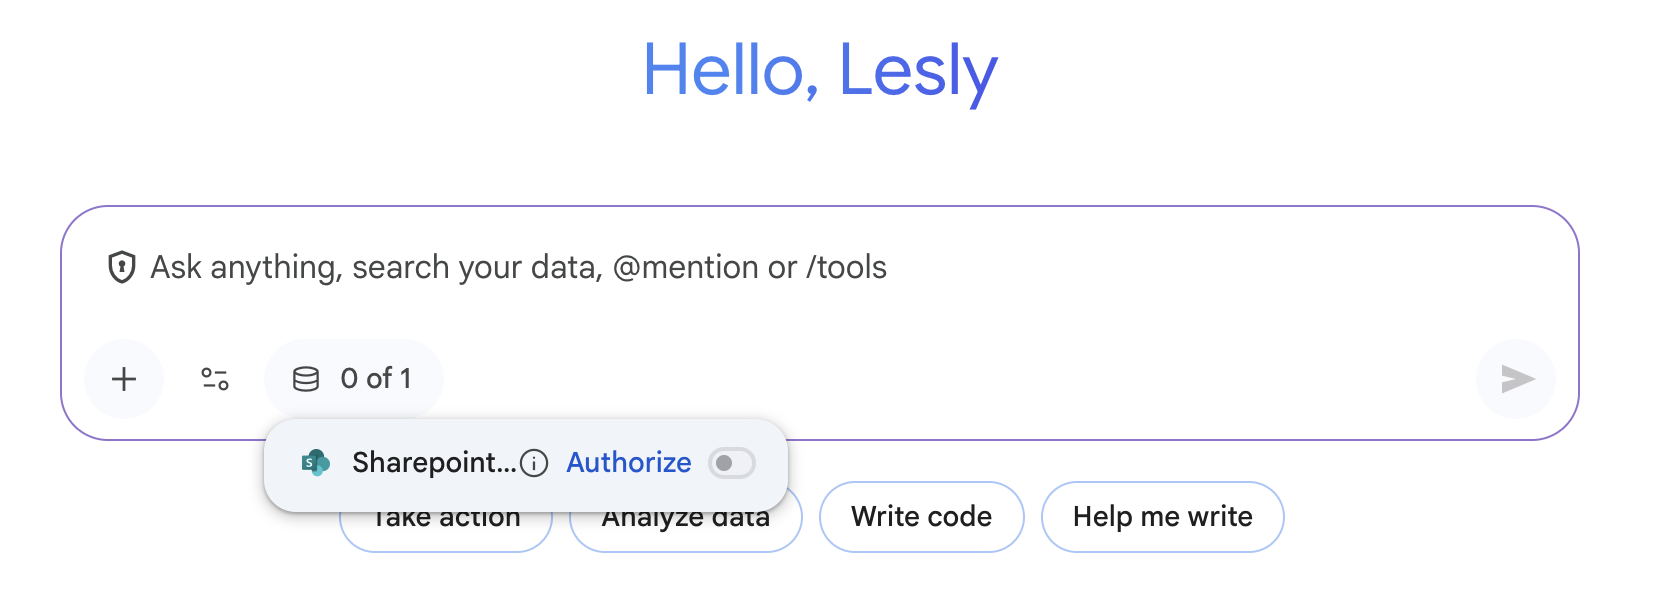

✅ If you see a screen similar to this one, you can jump to last section(**Finish Gemini Enterprise set up**
) if you do not want to add another connector.

# ✅ Set up OneDrive Connector (data ingestion)

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)
- To avoid ownsership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint



In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP OneDrive Ingestion "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://vertexaisearch.cloud.google.com/console/oauth/onedrive_oauth.html"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_ONEDRIVE_INGESTED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_ONEDRIVE_INGESTED'] = APP_ID_ONEDRIVE_INGESTED
    print(f"   -> Set environment variable APP_ID_ONEDRIVE_INGESTED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_ONEDRIVE_INGESTED,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

1- On the Select a data source page, scroll or search for SharePoint Online to connect your third-party source.
2- Copy the Subject identifier.

In [ ]:
# @title Get the subject identifier to set up Federated credentials
# @markdown Execute this cell, then on the Select a data source page, scroll or search for **SharePoint** to connect your third-party source. Copy and paste the **Subject identifier here**.

print("Click here to navigate to the page where you can copy the subject identifier👇 to paste below")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId&walkthrough_id=gemini-enterprise--connectors--onedrive-v1--create--quickstart")

def get_integer(prompt="Please enter the Subject Identifier copied on the page: "):
    """
    Prompts the user for input and waits until a valid integer is entered.
    """
    while True:
        user_input = input(prompt)
        try:
            # Attempt to convert the user's input to an integer
            number = int(user_input)
            # If successful, exit the loop and return the number
            return number
        except ValueError:
            # If the conversion fails, inform the user and loop again
            print("Invalid input. Please enter a whole number.")

# --- Using the function in Colab ---
ONEDRIVE_SUB_ID = get_integer("Please paste the Subject Identifier copied on the page and click ENTER:")

print(f"\nThank you! Subject Identifier is {ONEDRIVE_SUB_ID}. You can continue.")

In [ ]:
# @title Create Federated credential, Add Permissions, and Grant Consent
# @markdown ⬇️ Fill in the Application (client) ID of your app.
# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).

SitesAllPermissions = True  # @param {type:"boolean"}

import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
issuer_uri = "https://accounts.google.com"
subject = ONEDRIVE_SUB_ID
CREDENTIAL_NAME = "GCP_OneDrive_Federated_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Federated credential for accessing OneDrive from Gemini Enterprise" # @param {type:"string"}

credentials_json = {
    "name": CREDENTIAL_NAME,
    "issuer": issuer_uri,
    "subject": str(subject),
    "description": CREDENTIAL_DESCRIPTION,
    "audiences": [ "api://AzureADTokenExchange" ]
}

# Save the JSON to a temporary file
credentials_file_path = "/tmp/fed_creds.json"
with open(credentials_file_path, "w") as f:
    json.dump(credentials_json, f)

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {issuer_uri}")
print(f"   - Subject: {subject}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating federated credential '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_ONEDRIVE_INGESTED}'...")
az_command = [
    "az", "ad", "app", "federated-credential", "create",
    "--id", APP_ID_ONEDRIVE_INGESTED,
    "--parameters", f"@{credentials_file_path}"
]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Federated credential created successfully in Microsoft Entra ID.")
    print("\n--- Details ---")
    print(creation_result)


# --- 2. Find Microsoft Graph and its Permissions ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions: # read more https://cloud.google.com/gemini/enterprise/docs/connect-onedrive-ingestion#fed-cred-graph-permissions
  permissions_to_add.append("GroupMember.Read.All")
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Files.Read.All")


  permissions_to_add.append("Sites.FullControl.All")


  permissions_to_add.append("User.Read.All")
else: # read more https://cloud.google.com/gemini/enterprise/docs/connect-onedrive-ingestion#fed-cred-graph-permissions
  permissions_to_add.append("GroupMember.Read.All")
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Files.Read.All")

  permissions_to_add.append("Sites.Selected")

  permissions_to_add.append("User.ReadBasic.All")



required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_ONEDRIVE_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate

# --- 2b. Find Microsoft OneDrive and its Permissions ---
print("⚙️ Finding Office 365 OneDrive API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 Sharepoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add_onedrive = ["Sites.FullControl.All"]

else:
  permissions_to_add_onedrive = ["Sites.Selected"]
  print("When you use Sites.Selected, you must grant fullcontrol permission to the selected sites. Additionally, for this permission to take effect, you must do at least one of the following when creating the OneDrive connector in Gemini Enterprise: Read more on https://cloud.google.com/gemini/enterprise/docs/connect-onedrive-ingestion#onedrive-fed-auth-process")
  def get_sharepoint_url(prompt="Enter the OneDrive URL (e.g., mydomain.sharepoint.com/sites/sample-site): "):
    """
    Prompts the user for a OneDrive URL and validates it against the specific
    format 'domain.ondrive.com/sites/sitename'.
    """
    while True:
        # Get input and remove any leading/trailing whitespace
        url_input = input(prompt).strip()

        # 1. Check if the user included a forbidden scheme (http://, https://)
        if "://" in url_input:
            print("❌ Invalid format. Please enter the URL without 'https://' at the beginning.")
            continue

        # 2. Check for the required domain and path structure
        if ".sharepoint.com/sites/" not in url_input:
            print("❌ Invalid format. URL must contain '.sharepoint.com/sites/'.")
            continue

        # 3. Split the URL to do a final structure check
        parts = url_input.split('/')
        # It must have at least 3 parts: 'domain.com', 'sites', 'site-name'
        # And the first part must end with '.sharepoint.com'
        if len(parts) < 3 or not parts[0].endswith('.sharepoint.com'):
            print("❌ Invalid structure. Please ensure the format is 'mydomain.sharepoint.com/sites/sample-site'.")
            continue

        # If all checks pass, the format is correct
        return url_input
  ONEDRIVE_URL = get_sharepoint_url()
  print(f"\nThank you! Site is {ONEDRIVE_URL}. You can continue.")




required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add_onedrive:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3b. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_ONEDRIVE_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_ONEDRIVE_INGESTED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID_ONEDRIVE_INGESTED}")
print(f"Permissions Graph:     {permissions_to_add}")
print(f"Permissions OneDrive:     {permissions_to_add_onedrive}")
print(f"Credential name:     {CREDENTIAL_NAME}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

### Create the OneDrive Data Store (all Sites)

- Go back to the OneDrive Connector tab you opened earlier (the one with the Subject Identifier you copied)
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-onedrive-ingestion#onedrive-fed-auth-process)and execute code below to get details to copy/paste



In [ ]:
# @title Create OneDrive Data Store


def get_azure_tenant_domain():
    """
    Runs an Azure CLI command to get the signed-in user's tenant domain.

    Returns:
        str: The tenant domain (e.g., 'mycompany.onmicrosoft.com'), or None if an error occurs.
    """
    try:
        # Command to get the full User Principal Name (UPN)
        command = [
            "az", "ad", "signed-in-user", "show",
            "--query", "userPrincipalName",
            "--output", "tsv"
        ]

        # Execute the command
        result = subprocess.run(command, capture_output=True, text=True, check=True)

        # The output is the full UPN, e.g., "user@domain.com"
        user_principal_name = result.stdout.strip()

        # Split the UPN at the '@' and return the domain part
        if '@' in user_principal_name:
            return user_principal_name.split('@')[1]
        else:
            print("Error: Could not parse the User Principal Name.", file=sys.stderr)
            return None

    except FileNotFoundError:
        print("Error: 'az' command not found. Please run the Azure CLI installation cell.", file=sys.stderr)
        return None
    except subprocess.CalledProcessError as e:
        print("Error running Azure CLI command. Are you logged in?", file=sys.stderr)
        print(e.stderr, file=sys.stderr)
        return None


TENANT_DOMAIN = get_azure_tenant_domain()

FINAL_INSTANCE_URL = f"https://{TENANT_DOMAIN}.onedrive.com" if SitesAllPermissions else f"<Insert the Selected Site with the format https://{TENANT_DOMAIN}.onedrive.com/WEBSITE"
CONNECTOR_NAME = f"{TENANT_DOMAIN}-OneDrive-Connector" # @param

print(f"--- 📋 OneDrive data store configuration details ---")
print(f"Authentication method:         Federated Credentials")
print(f"Instance URI:         {FINAL_INSTANCE_URL}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client ID:         {APP_ID_ONEDRIVE_INGESTED}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


In [ ]:
# @title Link OneDrive Data Store to your Gemini Enterprise App
print("--- 🔗 Linking OneDrive data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--onedrive-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")

To check the status of your ingestion, go to the Data Stores page and click your data store name to see details about it on its Data page. The Connector state changes from Creating to Running when it starts synchronizing data. When ingestion is complete, the state changes to Active to indicate that the connection to your data source is set up and awaiting the next scheduled synchronization.
[Source](https://cloud.google.com/gemini/enterprise/docs/connect-onedrive-ingestion#onedrive-fed-auth-process)

# 🚧 Set up OneDrive Connector (data federation)

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)
- To avoid ownsership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint



In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Sharepoint Ingestion "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://vertexaisearch.cloud.google.com/console/oauth/sharepoint_oauth.html"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_SHAREPOINT_INGESTED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_SHAREPOINT_INGESTED'] = APP_ID_SHAREPOINT_INGESTED
    print(f"   -> Set environment variable APP_ID_SHAREPOINT_INGESTED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_SHAREPOINT_INGESTED,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

1- On the Select a data source page, scroll or search for SharePoint Online to connect your third-party source.
2- Copy the Subject identifier.

In [ ]:
# @title Get the subject identifier to set up Federated credentials
# @markdown Execute this cell, then on the Select a data source page, scroll or search for **SharePoint** to connect your third-party source. Copy and paste the **Subject identifier here**.

print("Click here to navigate to the page where you can copy the subject identifier👇 to paste below")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId&walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart")

def get_integer(prompt="Please enter the Subject Identifier copied on the page: "):
    """
    Prompts the user for input and waits until a valid integer is entered.
    """
    while True:
        user_input = input(prompt)
        try:
            # Attempt to convert the user's input to an integer
            number = int(user_input)
            # If successful, exit the loop and return the number
            return number
        except ValueError:
            # If the conversion fails, inform the user and loop again
            print("Invalid input. Please enter a whole number.")

# --- Using the function in Colab ---
SHAREPOINT_SUB_ID = get_integer("Please paste the Subject Identifier copied on the page and click ENTER:")

print(f"\nThank you! Subject Identifier is {SHAREPOINT_SUB_ID}. You can continue.")

In [ ]:
# @title Create Federated credential, Add Permissions, and Grant Consent
# @markdown ⬇️ Fill in the Application (client) ID of your app.
# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).

SitesAllPermissions = True  # @param {type:"boolean"}

import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
issuer_uri = "https://accounts.google.com"
subject = SHAREPOINT_SUB_ID
CREDENTIAL_NAME = "GCP_Sharepoint_Federated_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Federated credential for accessing SharePoint Online from Gemini Enterprise" # @param {type:"string"}

credentials_json = {
    "name": CREDENTIAL_NAME,
    "issuer": issuer_uri,
    "subject": str(subject),
    "description": CREDENTIAL_DESCRIPTION,
    "audiences": [ "api://AzureADTokenExchange" ]
}

# Save the JSON to a temporary file
credentials_file_path = "/tmp/fed_creds.json"
with open(credentials_file_path, "w") as f:
    json.dump(credentials_json, f)

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {issuer_uri}")
print(f"   - Subject: {subject}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating federated credential '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_SHAREPOINT_INGESTED}'...")
az_command = [
    "az", "ad", "app", "federated-credential", "create",
    "--id", APP_ID_SHAREPOINT_INGESTED,
    "--parameters", f"@{credentials_file_path}"
]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Federated credential created successfully in Microsoft Entra ID.")
    print("\n--- Details ---")
    print(creation_result)


# --- 2. Find Microsoft Graph and its Permissions ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.FullControl.All")
  permissions_to_add.append("User.Read.All")
else:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.Selected")
  permissions_to_add.append("User.ReadBasic.All")



required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate

# --- 2b. Find Microsoft Sharepoint and its Permissions ---
print("⚙️ Finding Office 365 SharePoint Online API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 SharePoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add_sharepoint = ["Sites.FullControl.All"]

else:
  permissions_to_add_sharepoint = ["Sites.Selected"]
  print("When you use Sites.Selected, you must grant fullcontrol permission to the selected sites. Read more on https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#grant-fullcontrol")
  def get_sharepoint_url(prompt="Enter the SharePoint Site URL (e.g., mydomain.sharepoint.com/sites/sample-site): "):
    """
    Prompts the user for a SharePoint URL and validates it against the specific
    format 'domain.sharepoint.com/sites/sitename'.
    """
    while True:
        # Get input and remove any leading/trailing whitespace
        url_input = input(prompt).strip()

        # 1. Check if the user included a forbidden scheme (http://, https://)
        if "://" in url_input:
            print("❌ Invalid format. Please enter the URL without 'https://' at the beginning.")
            continue

        # 2. Check for the required domain and path structure
        if ".sharepoint.com/sites/" not in url_input:
            print("❌ Invalid format. URL must contain '.sharepoint.com/sites/'.")
            continue

        # 3. Split the URL to do a final structure check
        parts = url_input.split('/')
        # It must have at least 3 parts: 'domain.com', 'sites', 'site-name'
        # And the first part must end with '.sharepoint.com'
        if len(parts) < 3 or not parts[0].endswith('.sharepoint.com'):
            print("❌ Invalid structure. Please ensure the format is 'mydomain.sharepoint.com/sites/sample-site'.")
            continue

        # If all checks pass, the format is correct
        return url_input
  SHAREPOINT_URL = get_sharepoint_url()
  print(f"\nThank you! Site is is {SHAREPOINT_URL}. You can continue.")




required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add_sharepoint:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3b. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_SHAREPOINT_INGESTED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Permissions:     {permissions_to_add}")
print(f"Credential name:     {CREDENTIAL_NAME}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

### Create the SharePoint Online Data Store (all Sites)

- Go back to the Sharepoint Online Connector tab you opened earlier (the one with the Subject Identifier you copied)
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-auth-process)and execute code below to get details to copy/paste



In [ ]:
# @title Create Sharepoint Online Data Store


def get_azure_tenant_domain():
    """
    Runs an Azure CLI command to get the signed-in user's tenant domain.

    Returns:
        str: The tenant domain (e.g., 'mycompany.onmicrosoft.com'), or None if an error occurs.
    """
    try:
        # Command to get the full User Principal Name (UPN)
        command = [
            "az", "ad", "signed-in-user", "show",
            "--query", "userPrincipalName",
            "--output", "tsv"
        ]

        # Execute the command
        result = subprocess.run(command, capture_output=True, text=True, check=True)

        # The output is the full UPN, e.g., "user@domain.com"
        user_principal_name = result.stdout.strip()

        # Split the UPN at the '@' and return the domain part
        if '@' in user_principal_name:
            return user_principal_name.split('@')[1]
        else:
            print("Error: Could not parse the User Principal Name.", file=sys.stderr)
            return None

    except FileNotFoundError:
        print("Error: 'az' command not found. Please run the Azure CLI installation cell.", file=sys.stderr)
        return None
    except subprocess.CalledProcessError as e:
        print("Error running Azure CLI command. Are you logged in?", file=sys.stderr)
        print(e.stderr, file=sys.stderr)
        return None


TENANT_DOMAIN = get_azure_tenant_domain()

FINAL_INSTANCE_URL = f"https://{TENANT_DOMAIN}.sharepoint.com" if SitesAllPermissions else f"<Insert the Selected Site with the format https://{TENANT_DOMAIN}.sharepoint.com/WEBSITE"
CONNECTOR_NAME = f"{TENANT_DOMAIN}-SharePoint-Connector" # @param

print(f"--- 📋 Sharepoint data store configuration details ---")
print(f"Authentication method:         Federated Credentials")
print(f"Instance URL:         {FINAL_INSTANCE_URL}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


In [ ]:
# @title Link Sharepoint Data Store to your Gemini Enterprise App
print("--- 🔗 Linking Sharepoint data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")

## [TODO] Option 2: Set up Sharepoint Online Ingestion connector with Selected Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)


# 🚧 Set up Outlook Connector (data federation)

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)
- To avoid ownsership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint



In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Sharepoint Ingestion "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://vertexaisearch.cloud.google.com/console/oauth/sharepoint_oauth.html"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_SHAREPOINT_INGESTED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_SHAREPOINT_INGESTED'] = APP_ID_SHAREPOINT_INGESTED
    print(f"   -> Set environment variable APP_ID_SHAREPOINT_INGESTED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_SHAREPOINT_INGESTED,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

1- On the Select a data source page, scroll or search for SharePoint Online to connect your third-party source.
2- Copy the Subject identifier.

In [ ]:
# @title Get the subject identifier to set up Federated credentials
# @markdown Execute this cell, then on the Select a data source page, scroll or search for **SharePoint** to connect your third-party source. Copy and paste the **Subject identifier here**.

print("Click here to navigate to the page where you can copy the subject identifier👇 to paste below")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId&walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart")

def get_integer(prompt="Please enter the Subject Identifier copied on the page: "):
    """
    Prompts the user for input and waits until a valid integer is entered.
    """
    while True:
        user_input = input(prompt)
        try:
            # Attempt to convert the user's input to an integer
            number = int(user_input)
            # If successful, exit the loop and return the number
            return number
        except ValueError:
            # If the conversion fails, inform the user and loop again
            print("Invalid input. Please enter a whole number.")

# --- Using the function in Colab ---
SHAREPOINT_SUB_ID = get_integer("Please paste the Subject Identifier copied on the page and click ENTER:")

print(f"\nThank you! Subject Identifier is {SHAREPOINT_SUB_ID}. You can continue.")

In [ ]:
# @title Create Federated credential, Add Permissions, and Grant Consent
# @markdown ⬇️ Fill in the Application (client) ID of your app.
# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).

SitesAllPermissions = True  # @param {type:"boolean"}

import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
issuer_uri = "https://accounts.google.com"
subject = SHAREPOINT_SUB_ID
CREDENTIAL_NAME = "GCP_Sharepoint_Federated_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Federated credential for accessing SharePoint Online from Gemini Enterprise" # @param {type:"string"}

credentials_json = {
    "name": CREDENTIAL_NAME,
    "issuer": issuer_uri,
    "subject": str(subject),
    "description": CREDENTIAL_DESCRIPTION,
    "audiences": [ "api://AzureADTokenExchange" ]
}

# Save the JSON to a temporary file
credentials_file_path = "/tmp/fed_creds.json"
with open(credentials_file_path, "w") as f:
    json.dump(credentials_json, f)

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {issuer_uri}")
print(f"   - Subject: {subject}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating federated credential '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_SHAREPOINT_INGESTED}'...")
az_command = [
    "az", "ad", "app", "federated-credential", "create",
    "--id", APP_ID_SHAREPOINT_INGESTED,
    "--parameters", f"@{credentials_file_path}"
]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Federated credential created successfully in Microsoft Entra ID.")
    print("\n--- Details ---")
    print(creation_result)


# --- 2. Find Microsoft Graph and its Permissions ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.FullControl.All")
  permissions_to_add.append("User.Read.All")
else:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.Selected")
  permissions_to_add.append("User.ReadBasic.All")



required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate

# --- 2b. Find Microsoft Sharepoint and its Permissions ---
print("⚙️ Finding Office 365 SharePoint Online API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 SharePoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add_sharepoint = ["Sites.FullControl.All"]

else:
  permissions_to_add_sharepoint = ["Sites.Selected"]
  print("When you use Sites.Selected, you must grant fullcontrol permission to the selected sites. Read more on https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#grant-fullcontrol")
  def get_sharepoint_url(prompt="Enter the SharePoint Site URL (e.g., mydomain.sharepoint.com/sites/sample-site): "):
    """
    Prompts the user for a SharePoint URL and validates it against the specific
    format 'domain.sharepoint.com/sites/sitename'.
    """
    while True:
        # Get input and remove any leading/trailing whitespace
        url_input = input(prompt).strip()

        # 1. Check if the user included a forbidden scheme (http://, https://)
        if "://" in url_input:
            print("❌ Invalid format. Please enter the URL without 'https://' at the beginning.")
            continue

        # 2. Check for the required domain and path structure
        if ".sharepoint.com/sites/" not in url_input:
            print("❌ Invalid format. URL must contain '.sharepoint.com/sites/'.")
            continue

        # 3. Split the URL to do a final structure check
        parts = url_input.split('/')
        # It must have at least 3 parts: 'domain.com', 'sites', 'site-name'
        # And the first part must end with '.sharepoint.com'
        if len(parts) < 3 or not parts[0].endswith('.sharepoint.com'):
            print("❌ Invalid structure. Please ensure the format is 'mydomain.sharepoint.com/sites/sample-site'.")
            continue

        # If all checks pass, the format is correct
        return url_input
  SHAREPOINT_URL = get_sharepoint_url()
  print(f"\nThank you! Site is is {SHAREPOINT_URL}. You can continue.")




required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add_sharepoint:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3b. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_SHAREPOINT_INGESTED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Permissions:     {permissions_to_add}")
print(f"Credential name:     {CREDENTIAL_NAME}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

### Create the SharePoint Online Data Store (all Sites)

- Go back to the Sharepoint Online Connector tab you opened earlier (the one with the Subject Identifier you copied)
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-auth-process)and execute code below to get details to copy/paste



In [ ]:
# @title Create Sharepoint Online Data Store


def get_azure_tenant_domain():
    """
    Runs an Azure CLI command to get the signed-in user's tenant domain.

    Returns:
        str: The tenant domain (e.g., 'mycompany.onmicrosoft.com'), or None if an error occurs.
    """
    try:
        # Command to get the full User Principal Name (UPN)
        command = [
            "az", "ad", "signed-in-user", "show",
            "--query", "userPrincipalName",
            "--output", "tsv"
        ]

        # Execute the command
        result = subprocess.run(command, capture_output=True, text=True, check=True)

        # The output is the full UPN, e.g., "user@domain.com"
        user_principal_name = result.stdout.strip()

        # Split the UPN at the '@' and return the domain part
        if '@' in user_principal_name:
            return user_principal_name.split('@')[1]
        else:
            print("Error: Could not parse the User Principal Name.", file=sys.stderr)
            return None

    except FileNotFoundError:
        print("Error: 'az' command not found. Please run the Azure CLI installation cell.", file=sys.stderr)
        return None
    except subprocess.CalledProcessError as e:
        print("Error running Azure CLI command. Are you logged in?", file=sys.stderr)
        print(e.stderr, file=sys.stderr)
        return None


TENANT_DOMAIN = get_azure_tenant_domain()

FINAL_INSTANCE_URL = f"https://{TENANT_DOMAIN}.sharepoint.com" if SitesAllPermissions else f"<Insert the Selected Site with the format https://{TENANT_DOMAIN}.sharepoint.com/WEBSITE"
CONNECTOR_NAME = f"{TENANT_DOMAIN}-SharePoint-Connector" # @param

print(f"--- 📋 Sharepoint data store configuration details ---")
print(f"Authentication method:         Federated Credentials")
print(f"Instance URL:         {FINAL_INSTANCE_URL}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


In [ ]:
# @title Link Sharepoint Data Store to your Gemini Enterprise App
print("--- 🔗 Linking Sharepoint data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")

## [TODO] Option 2: Set up Sharepoint Online Ingestion connector with Selected Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)


# 🚧 Set up Outlook Connector (data ingestion)

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)
- To avoid ownsership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint



In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Sharepoint Ingestion "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://vertexaisearch.cloud.google.com/console/oauth/sharepoint_oauth.html"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_SHAREPOINT_INGESTED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_SHAREPOINT_INGESTED'] = APP_ID_SHAREPOINT_INGESTED
    print(f"   -> Set environment variable APP_ID_SHAREPOINT_INGESTED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_SHAREPOINT_INGESTED,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

1- On the Select a data source page, scroll or search for SharePoint Online to connect your third-party source.
2- Copy the Subject identifier.

In [ ]:
# @title Get the subject identifier to set up Federated credentials
# @markdown Execute this cell, then on the Select a data source page, scroll or search for **SharePoint** to connect your third-party source. Copy and paste the **Subject identifier here**.

print("Click here to navigate to the page where you can copy the subject identifier👇 to paste below")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId&walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart")

def get_integer(prompt="Please enter the Subject Identifier copied on the page: "):
    """
    Prompts the user for input and waits until a valid integer is entered.
    """
    while True:
        user_input = input(prompt)
        try:
            # Attempt to convert the user's input to an integer
            number = int(user_input)
            # If successful, exit the loop and return the number
            return number
        except ValueError:
            # If the conversion fails, inform the user and loop again
            print("Invalid input. Please enter a whole number.")

# --- Using the function in Colab ---
SHAREPOINT_SUB_ID = get_integer("Please paste the Subject Identifier copied on the page and click ENTER:")

print(f"\nThank you! Subject Identifier is {SHAREPOINT_SUB_ID}. You can continue.")

In [ ]:
# @title Create Federated credential, Add Permissions, and Grant Consent
# @markdown ⬇️ Fill in the Application (client) ID of your app.
# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).

SitesAllPermissions = True  # @param {type:"boolean"}

import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
issuer_uri = "https://accounts.google.com"
subject = SHAREPOINT_SUB_ID
CREDENTIAL_NAME = "GCP_Sharepoint_Federated_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Federated credential for accessing SharePoint Online from Gemini Enterprise" # @param {type:"string"}

credentials_json = {
    "name": CREDENTIAL_NAME,
    "issuer": issuer_uri,
    "subject": str(subject),
    "description": CREDENTIAL_DESCRIPTION,
    "audiences": [ "api://AzureADTokenExchange" ]
}

# Save the JSON to a temporary file
credentials_file_path = "/tmp/fed_creds.json"
with open(credentials_file_path, "w") as f:
    json.dump(credentials_json, f)

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {issuer_uri}")
print(f"   - Subject: {subject}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating federated credential '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_SHAREPOINT_INGESTED}'...")
az_command = [
    "az", "ad", "app", "federated-credential", "create",
    "--id", APP_ID_SHAREPOINT_INGESTED,
    "--parameters", f"@{credentials_file_path}"
]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Federated credential created successfully in Microsoft Entra ID.")
    print("\n--- Details ---")
    print(creation_result)


# --- 2. Find Microsoft Graph and its Permissions ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.FullControl.All")
  permissions_to_add.append("User.Read.All")
else:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.Selected")
  permissions_to_add.append("User.ReadBasic.All")



required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate

# --- 2b. Find Microsoft Sharepoint and its Permissions ---
print("⚙️ Finding Office 365 SharePoint Online API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 SharePoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add_sharepoint = ["Sites.FullControl.All"]

else:
  permissions_to_add_sharepoint = ["Sites.Selected"]
  print("When you use Sites.Selected, you must grant fullcontrol permission to the selected sites. Read more on https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#grant-fullcontrol")
  def get_sharepoint_url(prompt="Enter the SharePoint Site URL (e.g., mydomain.sharepoint.com/sites/sample-site): "):
    """
    Prompts the user for a SharePoint URL and validates it against the specific
    format 'domain.sharepoint.com/sites/sitename'.
    """
    while True:
        # Get input and remove any leading/trailing whitespace
        url_input = input(prompt).strip()

        # 1. Check if the user included a forbidden scheme (http://, https://)
        if "://" in url_input:
            print("❌ Invalid format. Please enter the URL without 'https://' at the beginning.")
            continue

        # 2. Check for the required domain and path structure
        if ".sharepoint.com/sites/" not in url_input:
            print("❌ Invalid format. URL must contain '.sharepoint.com/sites/'.")
            continue

        # 3. Split the URL to do a final structure check
        parts = url_input.split('/')
        # It must have at least 3 parts: 'domain.com', 'sites', 'site-name'
        # And the first part must end with '.sharepoint.com'
        if len(parts) < 3 or not parts[0].endswith('.sharepoint.com'):
            print("❌ Invalid structure. Please ensure the format is 'mydomain.sharepoint.com/sites/sample-site'.")
            continue

        # If all checks pass, the format is correct
        return url_input
  SHAREPOINT_URL = get_sharepoint_url()
  print(f"\nThank you! Site is is {SHAREPOINT_URL}. You can continue.")




required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add_sharepoint:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3b. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_SHAREPOINT_INGESTED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Permissions:     {permissions_to_add}")
print(f"Credential name:     {CREDENTIAL_NAME}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

### Create the SharePoint Online Data Store (all Sites)

- Go back to the Sharepoint Online Connector tab you opened earlier (the one with the Subject Identifier you copied)
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-auth-process)and execute code below to get details to copy/paste



In [ ]:
# @title Create Sharepoint Online Data Store


def get_azure_tenant_domain():
    """
    Runs an Azure CLI command to get the signed-in user's tenant domain.

    Returns:
        str: The tenant domain (e.g., 'mycompany.onmicrosoft.com'), or None if an error occurs.
    """
    try:
        # Command to get the full User Principal Name (UPN)
        command = [
            "az", "ad", "signed-in-user", "show",
            "--query", "userPrincipalName",
            "--output", "tsv"
        ]

        # Execute the command
        result = subprocess.run(command, capture_output=True, text=True, check=True)

        # The output is the full UPN, e.g., "user@domain.com"
        user_principal_name = result.stdout.strip()

        # Split the UPN at the '@' and return the domain part
        if '@' in user_principal_name:
            return user_principal_name.split('@')[1]
        else:
            print("Error: Could not parse the User Principal Name.", file=sys.stderr)
            return None

    except FileNotFoundError:
        print("Error: 'az' command not found. Please run the Azure CLI installation cell.", file=sys.stderr)
        return None
    except subprocess.CalledProcessError as e:
        print("Error running Azure CLI command. Are you logged in?", file=sys.stderr)
        print(e.stderr, file=sys.stderr)
        return None


TENANT_DOMAIN = get_azure_tenant_domain()

FINAL_INSTANCE_URL = f"https://{TENANT_DOMAIN}.sharepoint.com" if SitesAllPermissions else f"<Insert the Selected Site with the format https://{TENANT_DOMAIN}.sharepoint.com/WEBSITE"
CONNECTOR_NAME = f"{TENANT_DOMAIN}-SharePoint-Connector" # @param

print(f"--- 📋 Sharepoint data store configuration details ---")
print(f"Authentication method:         Federated Credentials")
print(f"Instance URL:         {FINAL_INSTANCE_URL}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


In [ ]:
# @title Link Sharepoint Data Store to your Gemini Enterprise App
print("--- 🔗 Linking Sharepoint data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")

## [TODO] Option 2: Set up Sharepoint Online Ingestion connector with Selected Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)


# 🚧 Set up Entra ID Connector

## Option 1: Set up Sharepoint Online Ingestion connector with All Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)
- To avoid ownsership issue for the demo, ensure the user who is testing is Site Owner of the Sharepoint



In [ ]:
# @title Register new Entra App for Sharepoint Connector
import random
import string

# --- Generate a single random 4-character suffix ---
def generate_random_suffix(length=4):
    """Generates a random alphanumeric string of a given length."""
    characters = string.ascii_lowercase + string.digits  # a-z, 0-9
    return "".join(random.choices(characters, k=length))
# Generate the suffix that will be appended to all variables
random_suffix = generate_random_suffix()
#set random_suffix as os env variable

# @markdown ⬇️ Fill in your specific names and IDs here.
app_name = "GCP Sharepoint Ingestion "+random_suffix  # @param {type:"string"}

import subprocess
import json
import os

# --- 1. Construct the Redirect URI ---
redirect_uri = f"https://vertexaisearch.cloud.google.com/console/oauth/sharepoint_oauth.html"

print(f"✅ Using Redirect URI: {redirect_uri}\n")

# --- 2. Create the App Registration ---
print("⚙️ Creating the app registration...")
create_command = [
    "az", "ad", "app", "create",
    "--display-name", app_name,
    "--sign-in-audience", "AzureADMyOrg"
]

# Run the command and capture the JSON output
create_result = subprocess.run(create_command, capture_output=True, text=True)

if create_result.returncode != 0:
    print("❌ Error creating the app:")
    print(create_result.stderr)
else:
    print("👍 App created successfully.")
    app_details = json.loads(create_result.stdout)
    APP_ID_SHAREPOINT_INGESTED = app_details['appId']
    print(f"   Application (client) ID: {APP_ID}")

    # --- 2. SET THE ENVIRONMENT VARIABLE ---
    os.environ['APP_ID_SHAREPOINT_INGESTED'] = APP_ID_SHAREPOINT_INGESTED
    print(f"   -> Set environment variable APP_ID_SHAREPOINT_INGESTED\n")

    # --- 3. Add the Web Redirect URI ---
    print(f"⚙️ Adding web platform with redirect URI...")
    update_command = [
        "az", "ad", "app", "update",
        "--id", APP_ID_SHAREPOINT_INGESTED,
        "--web-redirect-uris", redirect_uri
    ]
    update_result = subprocess.run(update_command, capture_output=True, text=True)

    if update_result.returncode != 0:
        print("❌ Error updating the app with the redirect URI:")
        print(update_result.stderr)
    else:
        print("✅ Successfully configured the web redirect URI!")

1- On the Select a data source page, scroll or search for SharePoint Online to connect your third-party source.
2- Copy the Subject identifier.

In [ ]:
# @title Get the subject identifier to set up Federated credentials
# @markdown Execute this cell, then on the Select a data source page, scroll or search for **SharePoint** to connect your third-party source. Copy and paste the **Subject identifier here**.

print("Click here to navigate to the page where you can copy the subject identifier👇 to paste below")
print(f"https://console.cloud.google.com/gemini-enterprise/data-stores/create?orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId&walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart")

def get_integer(prompt="Please enter the Subject Identifier copied on the page: "):
    """
    Prompts the user for input and waits until a valid integer is entered.
    """
    while True:
        user_input = input(prompt)
        try:
            # Attempt to convert the user's input to an integer
            number = int(user_input)
            # If successful, exit the loop and return the number
            return number
        except ValueError:
            # If the conversion fails, inform the user and loop again
            print("Invalid input. Please enter a whole number.")

# --- Using the function in Colab ---
SHAREPOINT_SUB_ID = get_integer("Please paste the Subject Identifier copied on the page and click ENTER:")

print(f"\nThank you! Subject Identifier is {SHAREPOINT_SUB_ID}. You can continue.")

In [ ]:
# @title Create Federated credential, Add Permissions, and Grant Consent
# @markdown ⬇️ Fill in the Application (client) ID of your app.
# @markdown ⬇️ Uncheck the box if you want to grant permission for some Sharepoint Sites only (by default: grant readonly access to all Sharepoint Sites).

SitesAllPermissions = True  # @param {type:"boolean"}

import subprocess
import json
import sys
import time

# --- Helper function to run commands and handle errors ---
def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Error running command: {' '.join(command)}", file=sys.stderr)
        print(result.stderr, file=sys.stderr)
        return None
    return json.loads(result.stdout) if result.stdout.strip() else {}

# --- Construct the JSON credentials file content ---
issuer_uri = "https://accounts.google.com"
subject = SHAREPOINT_SUB_ID
CREDENTIAL_NAME = "GCP_Sharepoint_Federated_Credential-"+random_suffix # @param {type:"string"}
CREDENTIAL_DESCRIPTION = "Federated credential for accessing SharePoint Online from Gemini Enterprise" # @param {type:"string"}

credentials_json = {
    "name": CREDENTIAL_NAME,
    "issuer": issuer_uri,
    "subject": str(subject),
    "description": CREDENTIAL_DESCRIPTION,
    "audiences": [ "api://AzureADTokenExchange" ]
}

# Save the JSON to a temporary file
credentials_file_path = "/tmp/fed_creds.json"
with open(credentials_file_path, "w") as f:
    json.dump(credentials_json, f)

print("⚙️ Generated credentials file for Azure.")
print(f"   - Issuer: {issuer_uri}")
print(f"   - Subject: {subject}")

# --- Create the Federated Credential in Azure ---
print(f"\n⚙️ Creating federated credential '{CREDENTIAL_NAME}' on Azure App ID '{APP_ID_SHAREPOINT_INGESTED}'...")
az_command = [
    "az", "ad", "app", "federated-credential", "create",
    "--id", APP_ID_SHAREPOINT_INGESTED,
    "--parameters", f"@{credentials_file_path}"
]

# Print a readable version of the command being run
#print("   Running command:", " ".join(az_command))

creation_result = run_command(az_command)

if creation_result:
    print("\n✅ --- Success! --- ✅")
    print("Federated credential created successfully in Microsoft Entra ID.")
    print("\n--- Details ---")
    print(creation_result)


# --- 2. Find Microsoft Graph and its Permissions ---
print("⚙️ Finding Microsoft Graph API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Microsoft Graph", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.FullControl.All")
  permissions_to_add.append("User.Read.All")
else:
  permissions_to_add = ["GroupMember.Read.All"]
  permissions_to_add.append("User.Read")
  permissions_to_add.append("Sites.Selected")
  permissions_to_add.append("User.ReadBasic.All")



required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate

# --- 2b. Find Microsoft Sharepoint and its Permissions ---
print("⚙️ Finding Office 365 SharePoint Online API permissions...")
graph_sp = run_command(["az", "ad", "sp", "list", "--display-name", "Office 365 SharePoint Online", "--query", "[0]"])
if graph_sp is None:
    sys.exit(1)

if SitesAllPermissions:
  permissions_to_add_sharepoint = ["Sites.FullControl.All"]

else:
  permissions_to_add_sharepoint = ["Sites.Selected"]
  print("When you use Sites.Selected, you must grant fullcontrol permission to the selected sites. Read more on https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#grant-fullcontrol")
  def get_sharepoint_url(prompt="Enter the SharePoint Site URL (e.g., mydomain.sharepoint.com/sites/sample-site): "):
    """
    Prompts the user for a SharePoint URL and validates it against the specific
    format 'domain.sharepoint.com/sites/sitename'.
    """
    while True:
        # Get input and remove any leading/trailing whitespace
        url_input = input(prompt).strip()

        # 1. Check if the user included a forbidden scheme (http://, https://)
        if "://" in url_input:
            print("❌ Invalid format. Please enter the URL without 'https://' at the beginning.")
            continue

        # 2. Check for the required domain and path structure
        if ".sharepoint.com/sites/" not in url_input:
            print("❌ Invalid format. URL must contain '.sharepoint.com/sites/'.")
            continue

        # 3. Split the URL to do a final structure check
        parts = url_input.split('/')
        # It must have at least 3 parts: 'domain.com', 'sites', 'site-name'
        # And the first part must end with '.sharepoint.com'
        if len(parts) < 3 or not parts[0].endswith('.sharepoint.com'):
            print("❌ Invalid structure. Please ensure the format is 'mydomain.sharepoint.com/sites/sample-site'.")
            continue

        # If all checks pass, the format is correct
        return url_input
  SHAREPOINT_URL = get_sharepoint_url()
  print(f"\nThank you! Site is is {SHAREPOINT_URL}. You can continue.")




required_permission_ids = {}
for permission in graph_sp.get("appRoles", []):
    if permission.get("value") in permissions_to_add_sharepoint:
        required_permission_ids[permission.get("value")] = permission.get("id")

print("👍 Found necessary permission IDs.\n")


# --- 3b. Add API Permissions to your App ---
print("⚙️ Adding required API permissions to your app...")
for name, perm_id in required_permission_ids.items():
    print(f"   Adding permission: {name}")
    add_perm_command = ["az", "ad", "app", "permission", "add", "--id", APP_ID_SHAREPOINT_INGESTED, "--api", graph_sp["appId"], "--api-permissions", f"{perm_id}=Role"]
    subprocess.run(add_perm_command, capture_output=True) # Run without checking output as it can be slow to propagate


# --- 4. Grant Admin Consent ---
print("\n⚙️ Granting admin consent for the added permissions in 10 seconds from now...")

#Wait 10 seconds for proparation before admin consent
time.sleep(10)

grant_command = ["az", "ad", "app", "permission", "admin-consent", "--id", APP_ID_SHAREPOINT_INGESTED]
grant_result = run_command(grant_command)
if grant_result is not None:
    print("✅ Admin consent granted successfully!\n")


# --- 5. Display Final Configuration Details ---
print("--- 📋 Final Configuration Summary ---")
account_info = run_command(["az", "account", "show"])
TENANT_ID = account_info.get("tenantId")
ISSUER_URI = f"https://login.microsoftonline.com/{TENANT_ID}/v2.0"

print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Permissions:     {permissions_to_add}")
print(f"Credential name:     {CREDENTIAL_NAME}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Issuer URI:        {ISSUER_URI}")
print("-----------------------------------------")

### Create the SharePoint Online Data Store (all Sites)

- Go back to the Sharepoint Online Connector tab you opened earlier (the one with the Subject Identifier you copied)
- Instructions are available on [this page ](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-auth-process)and execute code below to get details to copy/paste



In [ ]:
# @title Create Sharepoint Online Data Store


def get_azure_tenant_domain():
    """
    Runs an Azure CLI command to get the signed-in user's tenant domain.

    Returns:
        str: The tenant domain (e.g., 'mycompany.onmicrosoft.com'), or None if an error occurs.
    """
    try:
        # Command to get the full User Principal Name (UPN)
        command = [
            "az", "ad", "signed-in-user", "show",
            "--query", "userPrincipalName",
            "--output", "tsv"
        ]

        # Execute the command
        result = subprocess.run(command, capture_output=True, text=True, check=True)

        # The output is the full UPN, e.g., "user@domain.com"
        user_principal_name = result.stdout.strip()

        # Split the UPN at the '@' and return the domain part
        if '@' in user_principal_name:
            return user_principal_name.split('@')[1]
        else:
            print("Error: Could not parse the User Principal Name.", file=sys.stderr)
            return None

    except FileNotFoundError:
        print("Error: 'az' command not found. Please run the Azure CLI installation cell.", file=sys.stderr)
        return None
    except subprocess.CalledProcessError as e:
        print("Error running Azure CLI command. Are you logged in?", file=sys.stderr)
        print(e.stderr, file=sys.stderr)
        return None


TENANT_DOMAIN = get_azure_tenant_domain()

FINAL_INSTANCE_URL = f"https://{TENANT_DOMAIN}.sharepoint.com" if SitesAllPermissions else f"<Insert the Selected Site with the format https://{TENANT_DOMAIN}.sharepoint.com/WEBSITE"
CONNECTOR_NAME = f"{TENANT_DOMAIN}-SharePoint-Connector" # @param

print(f"--- 📋 Sharepoint data store configuration details ---")
print(f"Authentication method:         Federated Credentials")
print(f"Instance URL:         {FINAL_INSTANCE_URL}")
print(f"Tenant ID:         {TENANT_ID}")
print(f"Client ID:         {APP_ID_SHAREPOINT_INGESTED}")
print(f"Click 'Continue' and configure the connector as per the documentation")
print(f"Data Connector Name:         {CONNECTOR_NAME}-{random_suffix}")


In [ ]:
# @title Link Sharepoint Data Store to your Gemini Enterprise App
print("--- 🔗 Linking Sharepoint data store to your Gemini Enterprise App ---")
print(f"Click here to link the Data Store: https://console.cloud.google.com/gemini-enterprise/locations/global/engines/{ENGINE_ID}/data-stores?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")
print(f"Click on **Add Existing Data Store** and select **{CONNECTOR_NAME}-{random_suffix}** and click **Connect**")

## [TODO] Option 2: Set up Sharepoint Online Ingestion connector with Selected Sites (Federated credentials)

- [Doc](https://cloud.google.com/gemini/enterprise/docs/connect-sharepoint-online-ingestion#sharepoint-fed-creds)


# 🏁 Finish Gemini Enterprise set up

---



In [ ]:
# @title Your Gemini Enterprise App is available. Bravo you did it! 👏
# @markdown Run the code to get the link to your Gemini Enterprise portal

#APP_URL = f"https://vertexaisearch.cloud.google.com/{LOCATION}/home/cid/{}}?hl=en_US"

from google.api_core.client_options import ClientOptions
from google.cloud import discoveryengine_v1 as discoveryengine

# TODO(developer): Uncomment these variables before running the sample.
# project_id = "YOUR_PROJECT_ID"
# location = "YOUR_LOCATION" # Values: "global"


def list_engines_sample(
    project_id: str,
    location: str,
) -> discoveryengine.ListEnginesResponse:
    #  For more information, refer to:
    # https://cloud.google.com/generative-ai-app-builder/docs/locations#specify_a_multi-region_for_your_data_store
    client_options = (
        ClientOptions(api_endpoint=f"{location}-discoveryengine.googleapis.com")
        if location != "global"
        else None
    )

    # Create a client
    client = discoveryengine.EngineServiceClient(client_options=client_options)

    # The full resource name of the parent collection
    # e.g. projects/{project}/locations/{location}/collections/default_collection
    parent = client.collection_path(
        project=PROJECT_ID,
        location=LOCATION,
        collection="default_collection",
    )

    # Make the request
    response = client.list_engines(parent=parent)

    # Handle response
    print(response)

    return response

#print(list_engines_sample(PROJECT_ID, LOCATION))

#print(f"Visit link to access to your Gemini Enterprise App: https://console.cloud.google.com/gemini-enterprise/apps?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")



print(f"Visit link to access to your Gemini Enterprise App: https://console.cloud.google.com/gemini-enterprise/locations/{LOCATION}/engines/{ENGINE_ID}/overview/dashboard?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")


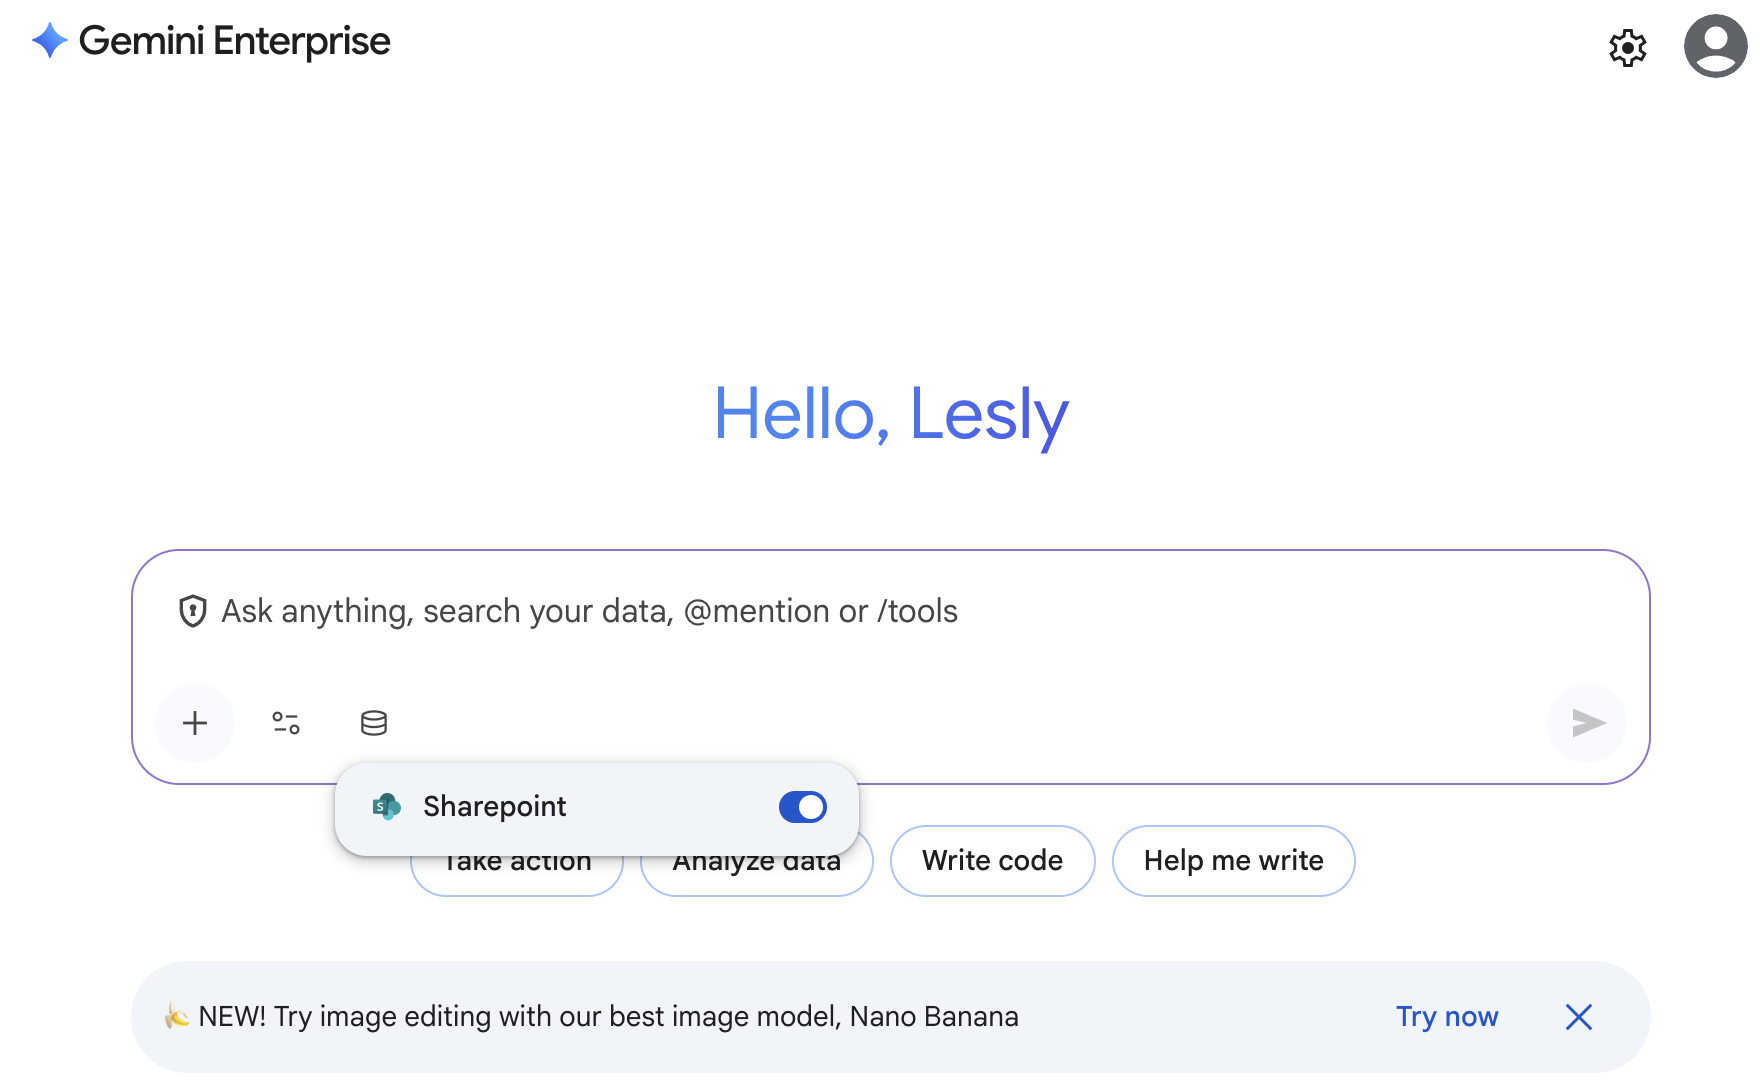

#Next Steps
- You can continue on the documentation to get your [Search Results](https://cloud.google.com/gemini/enterprise/docs/preview-search-results)

- If this notebook saved you hours feel free to ping me to let me know [@leslym](mailto:leslym@google.com)!


## [🔐Security] Setting up Model Armor


*   Reference [documentation](https://docs.cloud.google.com/gemini/enterprise/docs/enable-model-armor)



In [ ]:
# @title 🔐 1/ Setting the permissions and Model Armor API
# @markdown   Required roles:
# @markdown * To enable Model Armor in Gemini Enterprise: roles/discoveryengine.admin
# @markdown * To create the Model Armor templates: roles/modelarmor.admin
# @markdown * To call the Model Armor APIs: roles/modelarmor.user
CURRENT_USER_EMAIL=!gcloud config get-value account
CURRENT_USER="user:"+CURRENT_USER_EMAIL[0]
print(CURRENT_USER)
!gcloud projects add-iam-policy-binding {PROJECT_ID} \
    --member={CURRENT_USER} --role="roles/discoveryengine.admin"

!gcloud projects add-iam-policy-binding {PROJECT_ID} \
    --member={CURRENT_USER} --role="roles/modelarmor.admin"

!gcloud projects add-iam-policy-binding {PROJECT_ID} \
    --member={CURRENT_USER} --role="roles/modelarmor.user"

!gcloud services enable modelarmor.googleapis.com --project={PROJECT_ID}

In [ ]:
# @title 2/ Create a Model Armor template
# @markdown   Required roles:
# @markdown * To enable Model Armor in Gemini Enterprise: roles/discoveryengine.admin
# @markdown * To create the Model Armor templates: roles/modelarmor.admin
# @markdown * To call the Model Armor APIs: roles/modelarmor.user
MODEL_ARMOR_TEMPLATE_ID= "GeminiEnterprise-template-2" # @param {type:"string"}
MODEL_ARMOR_REGION= "us" # @param {type:"string"}
print(f"--- Creating Model Armor template {MODEL_ARMOR_TEMPLATE_ID} in project {PROJECT_ID} located in {MODEL_ARMOR_REGION} ---")

command = f"""
gcloud model-armor templates create {MODEL_ARMOR_TEMPLATE_ID} --project={PROJECT_ID}  --location={MODEL_ARMOR_REGION} \
     --rai-settings-filters='[{{ "filterType": "HATE_SPEECH", "confidenceLevel": "MEDIUM_AND_ABOVE" }},{{ "filterType": "HARASSMENT", "confidenceLevel": "MEDIUM_AND_ABOVE" }},{{ "filterType": "SEXUALLY_EXPLICIT", "confidenceLevel": "MEDIUM_AND_ABOVE" }}]' \
     --basic-config-filter-enforcement=enabled  \
     --pi-and-jailbreak-filter-settings-enforcement=enabled \
     --pi-and-jailbreak-filter-settings-confidence-level=LOW_AND_ABOVE \
     --malicious-uri-filter-settings-enforcement=enabled \
     --template-metadata-custom-llm-response-safety-error-code=798 \
     --template-metadata-custom-llm-response-safety-error-message="Gemini Enterprise Express: llm response evaluation failed" \
     --template-metadata-custom-prompt-safety-error-code=799 \
     --template-metadata-custom-prompt-safety-error-message="Gemini Enterprise Express: prompt evaluation failed" \
     --template-metadata-ignore-partial-invocation-failures \
     --template-metadata-log-operations \
     --template-metadata-log-sanitize-operations
"""
print(command)
!{command}

In [ ]:
# @title Link Model Armor template to your Gemini Enterprise App
print(f"--- Patching Model Armor settings for Gemini Enterprise {ENGINE_ID} in project {PROJECT_ID} ---")

MODEL_ARMOR_TEMPLATE_ID_URI= f"projects/{PROJECT_ID}/locations/{MODEL_ARMOR_REGION}/templates/{MODEL_ARMOR_TEMPLATE_ID}"


FAIL_MODE="FAIL_CLOSED"

command = f"""
curl -X PATCH \\
-H "Authorization: Bearer $(gcloud auth print-access-token)" \\
-H "Content-Type: application/json" \\
-H "X-Goog-User-Project: {PROJECT_ID}" \\
"https://{LOCATION}-discoveryengine.googleapis.com/v1alpha/projects/{PROJECT_ID}/locations/{LOCATION}/collections/default_collection/engines/{ENGINE_ID}/assistants/default_assistant?update_mask=customerPolicy" \\
-d '{{
  "customerPolicy": {{
    "modelArmorConfig": {{
      "userPromptTemplate": "{MODEL_ARMOR_TEMPLATE_ID_URI}",
      "responseTemplate": "{MODEL_ARMOR_TEMPLATE_ID_URI}",
      "failureMode": "{FAIL_MODE}"
    }}
  }}
}}'
"""

print("\n--- Command to be executed ---")
print(command)
print("-----------------------------\n")
!{command}


In [ ]:
# @title Try Model Armor rules in your Gemini Enterprise App
# @title Your Gemini Enterprise App is available. Bravo you did it! 👏
# @markdown Run the code to get the link to your Gemini Enterprise portal

#APP_URL = f"https://vertexaisearch.cloud.google.com/{LOCATION}/home/cid/{}}?hl=en_US"

from google.api_core.client_options import ClientOptions
from google.cloud import discoveryengine_v1 as discoveryengine

# TODO(developer): Uncomment these variables before running the sample.
# project_id = "YOUR_PROJECT_ID"
# location = "YOUR_LOCATION" # Values: "global"


def list_engines_sample(
    project_id: str,
    location: str,
) -> discoveryengine.ListEnginesResponse:
    #  For more information, refer to:
    # https://cloud.google.com/generative-ai-app-builder/docs/locations#specify_a_multi-region_for_your_data_store
    client_options = (
        ClientOptions(api_endpoint=f"{location}-discoveryengine.googleapis.com")
        if location != "global"
        else None
    )

    # Create a client
    client = discoveryengine.EngineServiceClient(client_options=client_options)

    # The full resource name of the parent collection
    # e.g. projects/{project}/locations/{location}/collections/default_collection
    parent = client.collection_path(
        project=PROJECT_ID,
        location=LOCATION,
        collection="default_collection",
    )

    # Make the request
    response = client.list_engines(parent=parent)

    # Handle response
    print(response)

    return response

#print(list_engines_sample(PROJECT_ID, LOCATION))

#print(f"Visit link to access to your Gemini Enterprise App: https://console.cloud.google.com/gemini-enterprise/apps?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")



print(f"Visit link to access to your Gemini Enterprise App: https://console.cloud.google.com/gemini-enterprise/locations/{LOCATION}/engines/{ENGINE_ID}/overview/dashboard?walkthrough_id=gemini-enterprise--connectors--sharepoint-v1--create--quickstart&orgonly=true&project={PROJECT_ID}&supportedpurview=organizationId")



print(f"Visit link to access to your Model Armor Monitoring dashboard: https://console.cloud.google.com/security/modelarmor/monitoring?project={PROJECT_ID}")